# Install Library

In [1]:
%pip install -q pandas numpy scikit-learn xgboost scipy matplotlib joblib

ERROR: Exception:
Traceback (most recent call last):
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/base_command.py", line 106, in _run_wrapper
    status = _inner_run()
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/base_command.py", line 97, in _inner_run
    return self.run(options, args)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/commands/install.py", line 484, in run
    installed_versions[distribution.canonical_name] = distribution.version
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/metadata/pkg_resources.py", line 192, in version
    return parse_version(self._dist.version)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_vendor/packaging/version

# Import dan Konfigurasi

In [2]:
from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import logit

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
N_SPLITS = 5
TARGET = "y_default_12bln"

MODEL_DIR = Path("models")
OUTPUT_DIR = Path("outputs")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# Load ABT PD dan Kamus Data

In [4]:
DATA_DIR = Path("../../data/gold").resolve()
PD_PATH = DATA_DIR / "abt_pd.parquet"

abt = pd.read_parquet(PD_PATH)

print("abt_pd shape :", abt.shape)
display(abt.head())

abt_pd shape : (4183, 93)


,application_id,facility_id,cif_sk,grup_id,angkatan,tanggal_pengajuan,tanggal_pencairan,snapshot_date,split,app_ada_agunan_likuid,app_ada_jaminan_silang,app_coverage_ratio,app_dokumen_ringkas,app_jenis_fasilitas,app_jumlah_agunan,app_kelas_penjualan,app_keputusan,app_komite_level,app_nama_produk,app_nilai_likuidasi_rp,app_penjualan_rp,app_plafon_diminta_rp,app_plafon_rp,app_plafon_thd_penjualan,app_pricing_bps,app_rating_internal,app_revolving,app_sektor_kbli,app_skor_kredit,app_tahun_berdiri,app_tenor_bulan,app_umur_perusahaan_tahun,fin_asset_turnover,fin_cfo_to_ebitda,fin_cfo_to_liability,fin_current_ratio,fin_debt_to_ebitda,fin_debt_to_ebitda_delta_3thn,fin_debt_to_ebitda_yoy,fin_der,fin_der_delta_3thn,fin_der_yoy,fin_dio_hari,fin_dso_hari,fin_ebitda_rp,fin_ekuitas_rp,fin_gross_margin,fin_growth_penjualan,fin_icr,fin_icr_delta_3thn,fin_icr_yoy,fin_laba_bersih_rp,fin_operating_margin,fin_penjualan_rp,fin_quick_ratio,fin_re_to_ta,fin_roa,fin_siklus_modal_kerja_hari,fin_total_aset_rp,fin_total_liabilitas_rp,fin_wc_to_ta,graf_betweenness,graf_buyer_concentration_hhi,graf_circular_payment_flag,graf_community_default_rate,graf_community_id,graf_degree,graf_group_exposure_share,graf_neighbor_default_rate_1hop,graf_node_emb_00,graf_node_emb_01,graf_node_emb_02,graf_node_emb_03,graf_node_emb_04,graf_node_emb_05,graf_node_emb_06,graf_node_emb_07,graf_node_emb_08,graf_node_emb_09,graf_node_emb_10,graf_node_emb_11,graf_node_emb_12,graf_node_emb_13,graf_node_emb_14,graf_node_emb_15,graf_pagerank,graf_shared_attribute_degree,graf_supplier_concentration_hhi,graf_weighted_degree,y_default_12bln,y_tersensor,y_umur_hari,y_umur_teramati_hari
0,1,1,1124,140,buku_lama,2022-01-01,2022-02-08,2021-12-31,latih,False,False,1.2023,False,investasi,3,Rp 30-50 M,setuju,Kepala Cabang,Kredit Investasi Bangunan,1.867200e+10,4.277115e+10,1.553000e+10,1.553000e+10,0.363095,959,B,False,G,5.50,2004,84,17,0.509336,NaN,-0.710799,1.016245,NaN,NaN,NaN,7.925952,6.231417,3.579021,1.936101,19.193640,-3.241894e+10,9.407883e+09,-0.471923,0.150985,-1.215080,-1.291359,10.778480,-6.936490e+10,-1.140538,4.277115e+10,0.970818,-2.468041,-0.826025,21.129742,8.397432e+10,7.456643e+10,0.001422,0.000196,0.543879,False,0.0,61,14,0.0,0.0,0.333410,0.299446,-0.017645,-0.011431,-0.001593,-0.007345,-0.006685,-0.005444,0.006909,0.009591,0.005943,0.004627,-0.000437,-0.001548,0.117216,0.116096,0.000137,0,0.539136,103.849932,0.0,False,NaN,1787.0
1,2,2,1317,3,buku_lama,2022-01-01,2022-01-27,2021-12-31,latih,False,True,1.5972,False,investasi,2,Rp 200-300 M,setuju,Komite Kredit Wilayah,Kredit Investasi Ekspansi,7.288800e+10,2.514976e+11,4.563400e+10,4.563400e+10,0.181449,783,BBB,False,J,66.73,2001,36,20,0.328870,0.622104,0.199114,1.130545,1.993076,-0.649963,-0.015646,1.332425,-0.159556,-0.046055,65.290551,99.923749,1.398243e+11,3.278703e+11,0.706988,0.054983,1.322187,-9.992238,-0.292853,1.239986e+10,0.259402,2.514976e+11,1.018378,0.361056,0.016215,165.214300,7.647328e+11,4.368625e+11,0.020061,0.000135,0.742713,False,0.0,41,9,0.0,0.0,0.261380,0.226145,-0.009099,-0.006914,-0.002783,-0.004291,0.000854,0.000714,0.075072,-0.084562,-0.004989,-0.003172,-0.001409,0.002546,0.026836,-0.030029,0.000071,0,0.991263,86.190695,0.0,False,NaN,1799.0
2,3,3,1807,1330,buku_lama,2022-01-01,2022-01-28,2021-12-31,latih,False,False,1.6508,True,investasi,1,Rp 200-300 M,setuju,Komite Kredit Wilayah,Kredit Investasi Bangunan,9.126600e+10,2.454024e+11,5.528500e+10,5.528500e+10,0.225283,796,BBB,False,G,74.10,2011,59,10,0.972113,0.729498,0.198402,0.893159,3.347613,-2.748997,-0.313824,2.250187,-2.598298,-0.454619,87.911070,47.507112,4.753289e+10,7.767002e+10,0.488146,0.133262,6.278335,5.658806,4.925666,2.449369e+10,0.152205,2.454024e+11,0.493467,0.380963,0.097027,135.418182,2.524421e+11,1.747721e+11,-0.032035,0.000062,0.507831,False,0.0,8,9,0.0,0.0,0.264878,0.231447,-0.013682,-0.007766,-0.005860,-0.001967,-0.007238,-0.002563,-0.000350,-0.005511,-0.001568,-0.006374,0.004150,-0.005920,-0.009658,-0.001443,0.000051,1,NaN,41.4

# Audit Schema dan Feature Blocks

In [6]:
required = [
    "application_id",
    "grup_id",
    "angkatan",
    "split",
    TARGET,
]

missing_required = [c for c in required if c not in abt.columns]
assert not missing_required, f"Kolom wajib hilang: {missing_required}"

block_summary = pd.DataFrame({
    "block": ["fin_*", "app_*", "graf_*", "y_*", "non-prefix"],
    "n_columns": [
        sum(c.startswith("fin_") for c in abt.columns),
        sum(c.startswith("app_") for c in abt.columns),
        sum(c.startswith("graf_") for c in abt.columns),
        sum(c.startswith("y_") for c in abt.columns),
        sum(not c.startswith(("fin_", "app_", "graf_", "y_")) for c in abt.columns),
    ],
})

display(block_summary)
assert abt.shape[0] == 4183
assert abt.shape[1] == 93

,block,n_columns
0,fin_*,29
1,app_*,23
2,graf_*,28
3,y_*,4
4,non-prefix,9


# Audit target, right censoring, split, dan Cohort

In [7]:
target_audit = pd.DataFrame({
    "metric": [
        "rows",
        "labeled",
        "right_censored",
        "defaults",
        "non_defaults",
    ],
    "value": [
        len(abt),
        int(abt[TARGET].notna().sum()),
        int(abt[TARGET].isna().sum()),
        int(abt[TARGET].sum(skipna=True)),
        int((abt[TARGET] == 0).sum()),
    ],
})

display(target_audit)

population_audit = (
    abt.groupby(["angkatan", "split"], dropna=False)
       .agg(
           rows=("application_id", "size"),
           labeled=(TARGET, "count"),
           defaults=(TARGET, "sum"),
           bad_rate=(TARGET, "mean"),
           censored=(TARGET, lambda s: s.isna().sum()),
       )
       .reset_index()
)

population_audit["bad_rate_pct"] = 100 * population_audit["bad_rate"]
display(population_audit)

,metric,value
0,rows,4183
1,labeled,4049
2,right_censored,134
3,defaults,129
4,non_defaults,3920


,angkatan,split,rows,labeled,defaults,bad_rate,censored,bad_rate_pct
0,buku_baru,latih,1589,1589,51.0,0.032096,0.0,3.209566
1,buku_baru,uji_oot,513,379,13.0,0.034301,134.0,3.430079
2,buku_lama,latih,2081,2081,65.0,0.031235,0.0,3.123498


# Cek Aturan Point in Time Snapshot

In [13]:
if {"tanggal_pengajuan", "snapshot_date"}.issubset(abt.columns):
    expected_snapshot = (
        abt["tanggal_pengajuan"]
        .dt.to_period("M")
        .dt.to_timestamp()
        - pd.Timedelta(days=1)
    )

    pit_ok = (
        abt["snapshot_date"].dt.normalize()
        == expected_snapshot.dt.normalize()
    )

    print("PIT snapshot valid:", pit_ok.mean())
    assert pit_ok.all(), "Ada snapshot yang bukan akhir bulan sebelum pengajuan."

PIT snapshot valid: 1.0


# EDA
Tujuannya bukan sekadar membuat chart, tetapi menjawab pertanyaan berikut:

1. Apakah struktur feature block sesuai desain?
2. Seberapa imbalanced target default?
3. Seberapa besar right-censoring?
4. Missing value mana yang paling penting?
5. Apakah bad rate berbeda antar cohort/split?
6. Apakah internal rating menunjukkan pola risiko yang masuk akal?
7. Bagaimana distribusi rasio keuangan utama?
8. Apakah ada korelasi sangat tinggi antar-feature?
9. Apakah historical network-default signal terlihat secara deskriptif?
10. Bagaimana volume pengajuan berubah sepanjang waktu?

## Struktur feature block

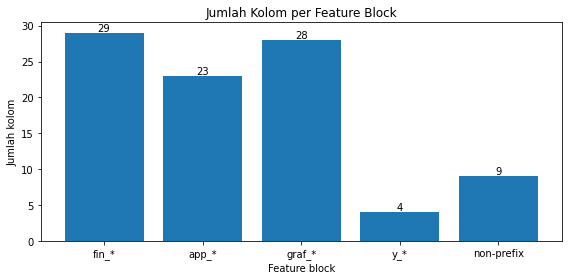

In [7]:
block_plot = block_summary.copy()

plt.figure(figsize=(8, 4))
bars = plt.bar(
    block_plot["block"],
    block_plot["n_columns"],
)

plt.title("Jumlah Kolom per Feature Block")
plt.xlabel("Feature block")
plt.ylabel("Jumlah kolom")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## Distribusi target: default, non-default, dan censored

Visual ini langsung menunjukkan dua isu modeling:
- **class imbalance**
- **right censoring**

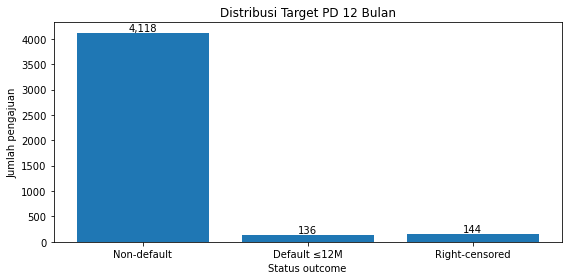

,status,n,share_pct
0,Non-default,4118,93.633470
1,Default ≤12M,136,3.092315
2,Right-censored,144,3.274216


In [8]:
target_status = pd.Series(
    np.where(
        abt[TARGET].isna(),
        "Right-censored",
        np.where(
            abt[TARGET].eq(1),
            "Default ≤12M",
            "Non-default",
        ),
    ),
    index=abt.index,
)

target_counts = (
    target_status
    .value_counts()
    .reindex([
        "Non-default",
        "Default ≤12M",
        "Right-censored",
    ])
)

plt.figure(figsize=(8, 4))
bars = plt.bar(
    target_counts.index,
    target_counts.values,
)

plt.title("Distribusi Target PD 12 Bulan")
plt.xlabel("Status outcome")
plt.ylabel("Jumlah pengajuan")

for bar, value in zip(bars, target_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        "status": target_counts.index,
        "n": target_counts.values,
        "share_pct": 100 * target_counts.values / target_counts.sum(),
    })
)

## Bad rate dan censoring per cohort × split

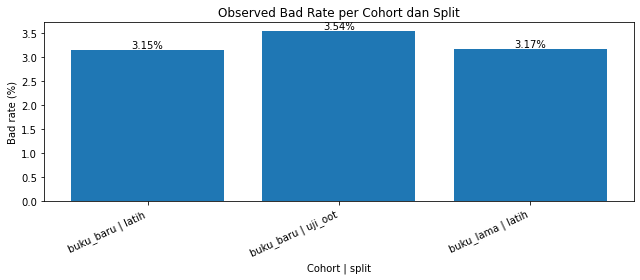

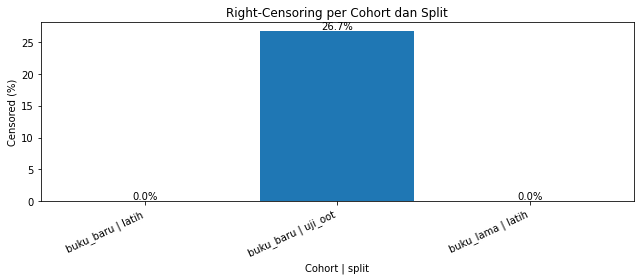

,angkatan,split,rows,labeled,defaults,bad_rate,censored,label,bad_rate_pct,censored_pct
0,buku_baru,latih,1681,1681,53.0,0.031529,0.0,buku_baru | latih,3.152885,0.000000
1,buku_baru,uji_oot,539,395,14.0,0.035443,144.0,buku_baru | uji_oot,3.544304,26.716141
2,buku_lama,latih,2178,2178,69.0,0.031680,0.0,buku_lama | latih,3.168044,0.000000


In [9]:
cohort_plot = (
    abt.groupby(["angkatan", "split"], dropna=False)
       .agg(
           rows=("application_id", "size"),
           labeled=(TARGET, "count"),
           defaults=(TARGET, "sum"),
           bad_rate=(TARGET, "mean"),
           censored=(TARGET, lambda s: s.isna().sum()),
       )
       .reset_index()
)

cohort_plot["label"] = (
    cohort_plot["angkatan"].astype(str)
    + " | "
    + cohort_plot["split"].astype(str)
)
cohort_plot["bad_rate_pct"] = 100 * cohort_plot["bad_rate"]
cohort_plot["censored_pct"] = 100 * cohort_plot["censored"] / cohort_plot["rows"]

plt.figure(figsize=(9, 4))
bars = plt.bar(
    cohort_plot["label"],
    cohort_plot["bad_rate_pct"],
)
plt.title("Observed Bad Rate per Cohort dan Split")
plt.xlabel("Cohort | split")
plt.ylabel("Bad rate (%)")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(bars, cohort_plot["bad_rate_pct"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
bars = plt.bar(
    cohort_plot["label"],
    cohort_plot["censored_pct"],
)
plt.title("Right-Censoring per Cohort dan Split")
plt.xlabel("Cohort | split")
plt.ylabel("Censored (%)")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(bars, cohort_plot["censored_pct"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

display(cohort_plot)

## Missing value profile

Chart ini membantu membedakan:
- missing karena **state yang meaningful**, seperti EBITDA ≤ 0
- missing karena **tidak ada relasi graph**
- missing karena **right censoring**
- missing biasa yang perlu imputasi

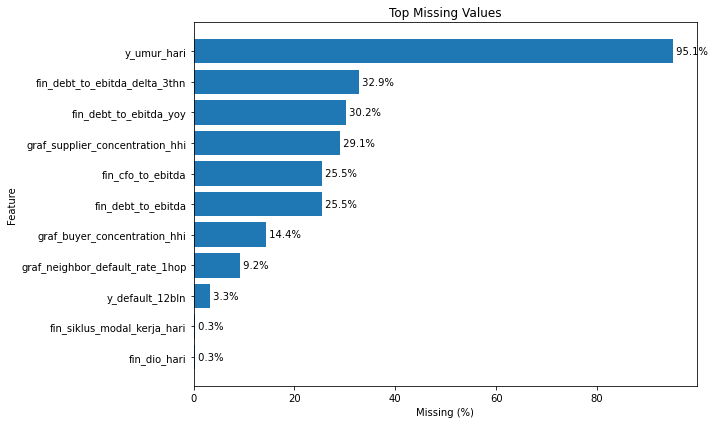

,feature,missing_n,missing_pct
0,y_umur_hari,4183,95.111414
1,fin_debt_to_ebitda_delta_3thn,1446,32.878581
2,fin_debt_to_ebitda_yoy,1330,30.241019
3,graf_supplier_concentration_hhi,1281,29.126876
4,fin_debt_to_ebitda,1121,25.488859
5,fin_cfo_to_ebitda,1121,25.488859
6,graf_buyer_concentration_hhi,635,14.438381
7,graf_neighbor_default_rate_1hop,404,9.185994
8,y_default_12bln,144,3.274216
9,fin_dio_hari,12,0.272851


In [10]:
missing = (
    abt.isna()
       .sum()
       .sort_values(ascending=False)
)

missing = missing[missing > 0].head(15)

missing_df = pd.DataFrame({
    "feature": missing.index,
    "missing_n": missing.values,
})
missing_df["missing_pct"] = (
    100 * missing_df["missing_n"] / len(abt)
)

plot_df = missing_df.sort_values("missing_pct")

plt.figure(figsize=(10, 6))
bars = plt.barh(
    plot_df["feature"],
    plot_df["missing_pct"],
)

plt.title("Top Missing Values")
plt.xlabel("Missing (%)")
plt.ylabel("Feature")

for bar, value in zip(bars, plot_df["missing_pct"]):
    plt.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f" {value:.1f}%",
        va="center",
    )

plt.tight_layout()
plt.show()

display(missing_df)

## Bad rate per internal rating

Visual ini dipakai sebagai **sanity check**: secara umum rating yang makin buruk seharusnya menunjukkan risiko yang makin tinggi, walaupun tidak harus monotonic sempurna karena jumlah observasi kategori ekstrem sangat kecil.

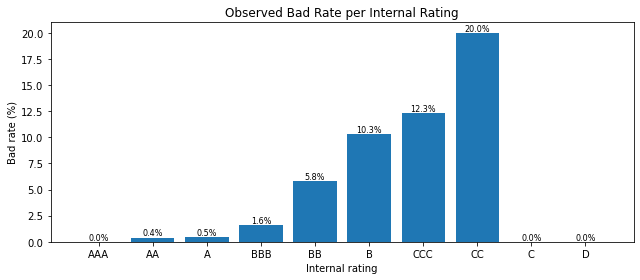

,app_rating_internal,n,defaults,bad_rate,bad_rate_pct
0,AAA,19,0.0,0.000000,0.000000
1,AA,247,1.0,0.004049,0.404858
2,A,1065,5.0,0.004695,0.469484
3,BBB,1520,24.0,0.015789,1.578947
4,BB,893,52.0,0.058231,5.823068
5,B,428,44.0,0.102804,10.280374
6,CCC,73,9.0,0.123288,12.328767
7,CC,5,1.0,0.200000,20.000000
8,C,3,0.0,0.000000,0.000000
9,D,1,0.0,0.000000,0.000000


In [11]:
rating_order = [
    "AAA", "AA", "A", "BBB", "BB",
    "B", "CCC", "CC", "C", "D",
]

rating_stats = (
    abt.loc[abt[TARGET].notna()]
       .groupby("app_rating_internal")
       .agg(
           n=(TARGET, "size"),
           defaults=(TARGET, "sum"),
           bad_rate=(TARGET, "mean"),
       )
       .reindex(rating_order)
       .dropna(how="all")
       .reset_index()
)

rating_stats["bad_rate_pct"] = 100 * rating_stats["bad_rate"]

plt.figure(figsize=(9, 4))
bars = plt.bar(
    rating_stats["app_rating_internal"],
    rating_stats["bad_rate_pct"],
)

plt.title("Observed Bad Rate per Internal Rating")
plt.xlabel("Internal rating")
plt.ylabel("Bad rate (%)")

for bar, value in zip(bars, rating_stats["bad_rate_pct"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

display(rating_stats)

## Distribusi financial feature utama

Histogram dibuat satu per satu supaya setiap feature mudah dibaca.

Feature yang divisualisasikan:
- DER
- ICR
- ROA
- Current Ratio
- Quick Ratio
- DSO

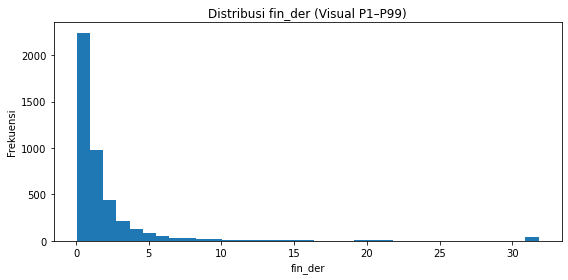

fin_der | median = 0.9284 | P1 = 0.0461 | P99 = 31.8068


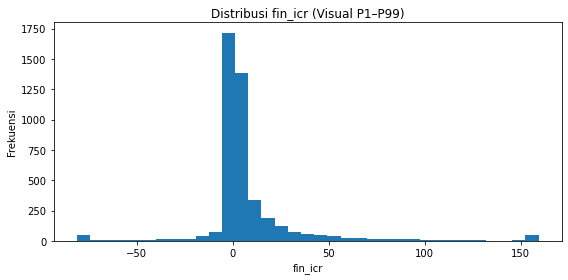

fin_icr | median = 1.9965 | P1 = -81.102 | P99 = 159.323


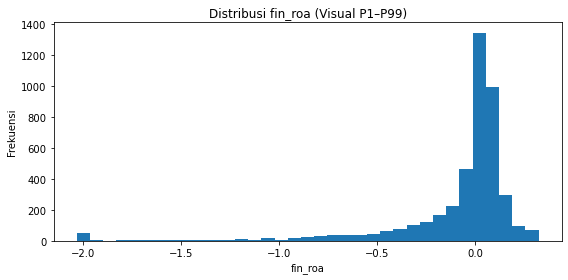

fin_roa | median = 0.0248 | P1 = -2.0315 | P99 = 0.324


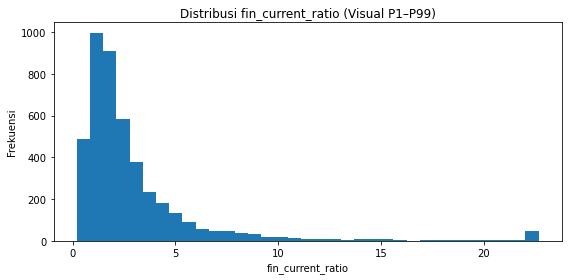

fin_current_ratio | median = 1.9767 | P1 = 0.2078 | P99 = 22.6603


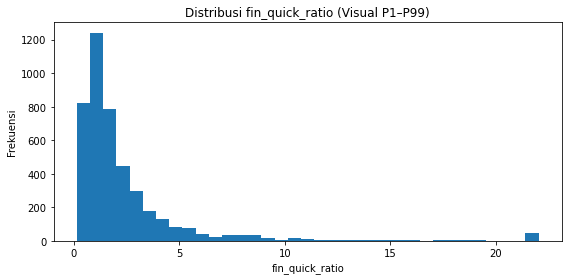

fin_quick_ratio | median = 1.4845 | P1 = 0.1447 | P99 = 22.0115


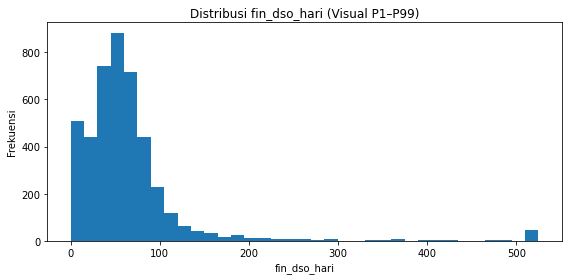

fin_dso_hari | median = 53.8015 | P1 = 0.0 | P99 = 524.4224


In [12]:
financial_visual_features = [
    "fin_der",
    "fin_icr",
    "fin_roa",
    "fin_current_ratio",
    "fin_quick_ratio",
    "fin_dso_hari",
]

for col in financial_visual_features:
    if col not in abt.columns:
        continue

    x = pd.to_numeric(
        abt[col],
        errors="coerce",
    ).dropna()

    # Winsorized hanya untuk visual agar extreme outlier
    # tidak membuat mayoritas distribusi tidak terbaca.
    lower = x.quantile(0.01)
    upper = x.quantile(0.99)
    x_plot = x.clip(lower, upper)

    plt.figure(figsize=(8, 4))
    plt.hist(
        x_plot,
        bins=35,
    )
    plt.title(
        f"Distribusi {col} (Visual P1–P99)"
    )
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

    print(
        col,
        "| median =", round(x.median(), 4),
        "| P1 =", round(lower, 4),
        "| P99 =", round(upper, 4),
    )

## Requested exposure distribution

Untuk exposure rupiah yang sangat skewed, visual memakai `log10(1 + plafon)` agar bentuk distribusi dapat terbaca. Nilai asli tetap tidak diubah untuk modeling.

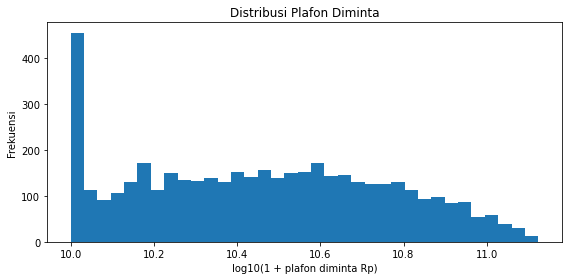

,app_plafon_diminta_rp
count,4.398000e+03
mean,3.641767e+10
std,2.558858e+10
min,1.000000e+10
25%,1.593350e+10
50%,2.875000e+10
75%,4.936575e+10
90%,7.531570e+10
95%,9.025850e+10
99%,1.146165e+11


In [13]:
if "app_plafon_diminta_rp" in abt.columns:
    plafon = pd.to_numeric(
        abt["app_plafon_diminta_rp"],
        errors="coerce",
    ).dropna()

    plt.figure(figsize=(8, 4))
    plt.hist(
        np.log10(1 + plafon),
        bins=35,
    )

    plt.title("Distribusi Plafon Diminta")
    plt.xlabel("log10(1 + plafon diminta Rp)")
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

    display(
        plafon.describe(
            percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
        ).to_frame("app_plafon_diminta_rp")
    )

## Historical neighbor-default signal

Ini salah satu visual yang penting untuk cerita **Graph Analytics**.

Kita membandingkan bad rate debitur:
- tanpa historical default neighbor
- punya minimal satu historical default neighbor

Visual ini hanya menggunakan target yang sudah observed.

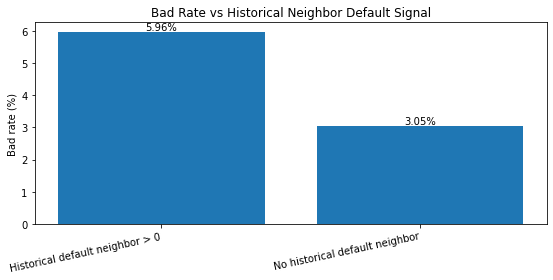

,neighbor_signal,n,defaults,bad_rate,bad_rate_pct
0,Historical default neighbor > 0,218,13.0,0.059633,5.963303
1,No historical default neighbor,4036,123.0,0.030476,3.047572


In [14]:
if "graf_neighbor_default_rate_1hop" in abt.columns:
    graph_signal = (
        abt.loc[abt[TARGET].notna()]
           .copy()
    )

    graph_signal["neighbor_signal"] = np.where(
        graph_signal[
            "graf_neighbor_default_rate_1hop"
        ].fillna(0).gt(0),
        "Historical default neighbor > 0",
        "No historical default neighbor",
    )

    neighbor_stats = (
        graph_signal.groupby("neighbor_signal")
                    .agg(
                        n=(TARGET, "size"),
                        defaults=(TARGET, "sum"),
                        bad_rate=(TARGET, "mean"),
                    )
                    .reset_index()
    )

    neighbor_stats["bad_rate_pct"] = (
        100 * neighbor_stats["bad_rate"]
    )

    plt.figure(figsize=(8, 4))
    bars = plt.bar(
        neighbor_stats["neighbor_signal"],
        neighbor_stats["bad_rate_pct"],
    )

    plt.title("Bad Rate vs Historical Neighbor Default Signal")
    plt.xlabel("")
    plt.ylabel("Bad rate (%)")
    plt.xticks(rotation=12, ha="right")

    for bar, value in zip(
        bars,
        neighbor_stats["bad_rate_pct"],
    ):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    display(neighbor_stats)

## Community default rate — risk buckets

`community_default_rate` lebih informatif bila dilihat sebagai level risiko, bukan community ID.

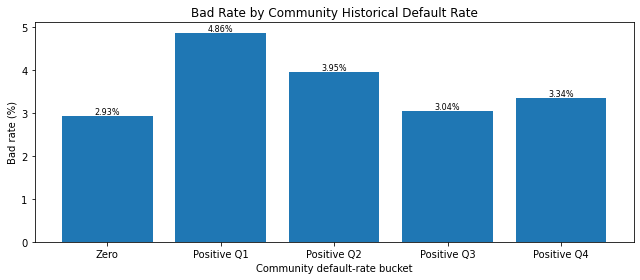

,community_risk_bucket,n,defaults,bad_rate,bad_rate_pct
4,Zero,2938,86.0,0.029272,2.927161
0,Positive Q1,329,16.0,0.048632,4.863222
1,Positive Q2,329,13.0,0.039514,3.951368
2,Positive Q3,329,10.0,0.030395,3.039514
3,Positive Q4,329,11.0,0.033435,3.343465


In [15]:
if "graf_community_default_rate" in abt.columns:
    tmp = (
        abt.loc[
            abt[TARGET].notna(),
            [
                "graf_community_default_rate",
                TARGET,
            ],
        ]
        .copy()
    )

    tmp[
        "graf_community_default_rate"
    ] = tmp[
        "graf_community_default_rate"
    ].fillna(0)

    positive = (
        tmp["graf_community_default_rate"] > 0
    )

    tmp["community_risk_bucket"] = "Zero"

    if positive.sum() >= 4:
        tmp.loc[
            positive,
            "community_risk_bucket",
        ] = pd.qcut(
            tmp.loc[
                positive,
                "graf_community_default_rate",
            ].rank(method="first"),
            q=4,
            labels=[
                "Positive Q1",
                "Positive Q2",
                "Positive Q3",
                "Positive Q4",
            ],
        ).astype(str)

    community_stats = (
        tmp.groupby(
            "community_risk_bucket"
        )
        .agg(
            n=(TARGET, "size"),
            defaults=(TARGET, "sum"),
            bad_rate=(TARGET, "mean"),
        )
        .reset_index()
    )

    order = [
        "Zero",
        "Positive Q1",
        "Positive Q2",
        "Positive Q3",
        "Positive Q4",
    ]

    community_stats["community_risk_bucket"] = pd.Categorical(
        community_stats["community_risk_bucket"],
        categories=order,
        ordered=True,
    )

    community_stats = (
        community_stats
        .sort_values("community_risk_bucket")
    )

    community_stats["bad_rate_pct"] = (
        100 * community_stats["bad_rate"]
    )

    plt.figure(figsize=(9, 4))
    bars = plt.bar(
        community_stats[
            "community_risk_bucket"
        ].astype(str),
        community_stats["bad_rate_pct"],
    )

    plt.title("Bad Rate by Community Historical Default Rate")
    plt.xlabel("Community default-rate bucket")
    plt.ylabel("Bad rate (%)")

    for bar, value in zip(
        bars,
        community_stats["bad_rate_pct"],
    ):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            value,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

    display(community_stats)

## Volume pengajuan sepanjang waktu

Grafik ini mengecek temporal coverage dan membantu memahami kenapa kita menggunakan out-of-time evaluation.

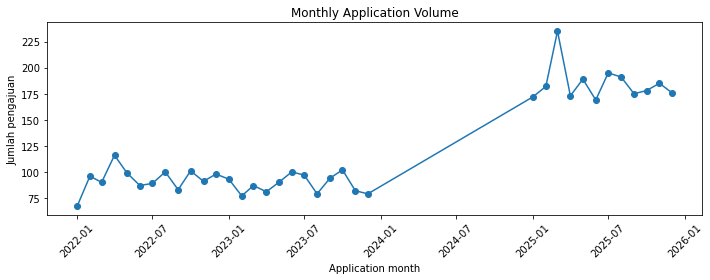

,application_month,applications
24,2025-01-01,172
25,2025-02-01,182
26,2025-03-01,235
27,2025-04-01,173
28,2025-05-01,189
29,2025-06-01,169
30,2025-07-01,195
31,2025-08-01,191
32,2025-09-01,175
33,2025-10-01,178


In [16]:
if "tanggal_pengajuan" in abt.columns:
    monthly_app = (
        abt.assign(
            application_month=
                abt["tanggal_pengajuan"]
                .dt.to_period("M")
                .dt.to_timestamp()
        )
        .groupby("application_month")
        .size()
        .rename("applications")
        .reset_index()
    )

    plt.figure(figsize=(10, 4))
    plt.plot(
        monthly_app["application_month"],
        monthly_app["applications"],
        marker="o",
    )
    plt.title("Monthly Application Volume")
    plt.xlabel("Application month")
    plt.ylabel("Jumlah pengajuan")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(monthly_app.tail(12))

## Cek Disribusi Graph

In [17]:
# ============================================================
# DAFTAR FITUR GRAPH
# ============================================================

graph_features = [
    c for c in abt.columns
    if c.startswith("graf_")
]

print(
    "Jumlah graph features:",
    len(graph_features)
)

print(graph_features)

Jumlah graph features: 28
['graf_betweenness', 'graf_buyer_concentration_hhi', 'graf_circular_payment_flag', 'graf_community_default_rate', 'graf_community_id', 'graf_degree', 'graf_group_exposure_share', 'graf_neighbor_default_rate_1hop', 'graf_node_emb_00', 'graf_node_emb_01', 'graf_node_emb_02', 'graf_node_emb_03', 'graf_node_emb_04', 'graf_node_emb_05', 'graf_node_emb_06', 'graf_node_emb_07', 'graf_node_emb_08', 'graf_node_emb_09', 'graf_node_emb_10', 'graf_node_emb_11', 'graf_node_emb_12', 'graf_node_emb_13', 'graf_node_emb_14', 'graf_node_emb_15', 'graf_pagerank', 'graf_shared_attribute_degree', 'graf_supplier_concentration_hhi', 'graf_weighted_degree']


In [18]:
# ============================================================
# GRAPH FEATURE TYPE IDENTIFICATION
# ============================================================

graph_cols_all = [
    c for c in abt.columns
    if c.startswith("graf_")
]

print(
    "Total graph features:",
    len(graph_cols_all)
)

Total graph features: 28


In [19]:
# ============================================================
# MANUAL CATEGORICAL GRAPH FEATURES
# ============================================================

graph_categorical_cols = [
    c for c in [
        "graf_community_id",
    ]
    if c in graph_cols_all
]

In [20]:
# ============================================================
# BOOLEAN / BINARY GRAPH FEATURES
# ============================================================

graph_boolean_cols = []

for col in graph_cols_all:

    if col in graph_categorical_cols:
        continue

    unique_values = (
        abt[col]
        .dropna()
        .unique()
    )

    if len(unique_values) <= 2:

        graph_boolean_cols.append(
            col
        )

In [21]:
# ============================================================
# NUMERICAL GRAPH FEATURES
# ============================================================

graph_numeric_cols = [

    c for c in graph_cols_all

    if c not in (
        graph_categorical_cols
        + graph_boolean_cols
    )
]

In [22]:
# ============================================================
# NUMERICAL GRAPH SUMMARY
# ============================================================

numeric_summary = []


for col in graph_numeric_cols:

    s = pd.to_numeric(
        abt[col],
        errors="coerce"
    )


    numeric_summary.append({

        "feature":
            col,

        "missing_pct":
            100 * s.isna().mean(),

        "zero_pct":
            100 * (
                s.fillna(0) == 0
            ).mean(),

        "mean":
            s.mean(),

        "std":
            s.std(),

        "min":
            s.min(),

        "p01":
            s.quantile(0.01),

        "p25":
            s.quantile(0.25),

        "median":
            s.median(),

        "p75":
            s.quantile(0.75),

        "p99":
            s.quantile(0.99),

        "max":
            s.max(),

        "n_unique":
            s.nunique(),
    })


numeric_summary = (
    pd.DataFrame(
        numeric_summary
    )
    .sort_values(
        "zero_pct",
        ascending=False
    )
)


display(
    numeric_summary
)

,feature,missing_pct,zero_pct,mean,std,min,p01,p25,median,p75,p99,max,n_unique
5,graf_neighbor_default_rate_1hop,9.185994,94.702137,1.150482e-02,6.025216e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.333333e-01,1.000000e+00,40
2,graf_community_default_rate,0.000000,68.553888,1.001900e-02,2.298529e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.102941e-02,1.000000e-01,5.000000e-01,83
23,graf_shared_attribute_degree,0.000000,63.392451,1.934743e+00,4.087631e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.900000e+01,2.700000e+01,26
4,graf_group_exposure_share,0.000000,34.720327,2.627017e-02,4.688087e-02,0.000000e+00,0.000000e+00,0.000000e+00,8.124500e-03,3.094400e-02,2.422680e-01,3.887000e-01,2184
24,graf_supplier_concentration_hhi,29.126876,29.126876,8.128392e-01,2.292088e-01,3.763210e-02,2.563130e-01,6.174705e-01,9.477515e-01,1.000000e+00,1.000000e+00,1.000000e+00,2021
1,graf_buyer_concentration_hhi,14.438381,14.438381,8.335338e-01,2.062945e-01,2.582062e-01,3.386832e-01,6.699433e-01,9.576966e-01,1.000000e+00,1.000000e+00,1.000000e+00,2469
0,graf_betweenness,0.000000,2.569350,4.881052e-04,7.282160e-03,0.000000e+00,0.000000e+00,4.369846e-05,1.026645e-04,2.405699e-04,7.131397e-03,4.710102e-01,4161
20,graf_node_emb_14,0.000000,0.136426,9.073879e+08,5.386544e+10,-7.425530e+00,-8.568968e-04,-5.124818e-08,-5.266502e-12,1.097168e-11,7.470504e-05,3.544320e+12,4393
15,graf_node_emb_09,0.000000,0.113688,8.251487e+09,4.047604e+11,-1.290196e+07,-1.809725e+04,-5.962178e-07,1.843713e-07,3.919924e-02,2.260923e+04,2.372164e+13,4394
21,graf_node_emb_15,0.000000,0.113688,3.811389e+09,2.512365e+11,-1.600955e+01,-4.499671e-04,-7.397691e-09,-2.123565e-13,1.285106e-10,1.788679e-04,1.666107e+13,4394


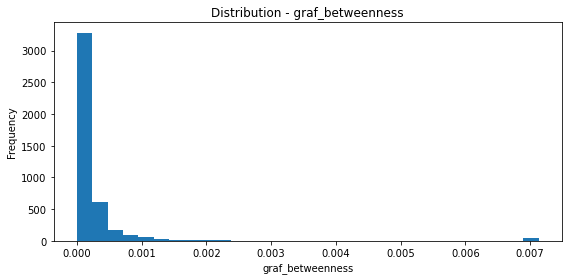

Feature     : graf_betweenness
Missing (%) : 0.00
Zero (%)    : 2.57
Median      : 0.0001
P99         : 0.0071
------------------------------------------------------------


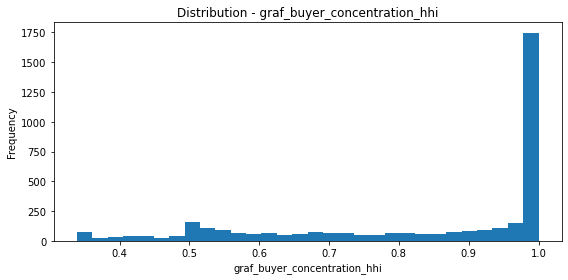

Feature     : graf_buyer_concentration_hhi
Missing (%) : 14.44
Zero (%)    : 14.44
Median      : 0.9577
P99         : 1.0000
------------------------------------------------------------


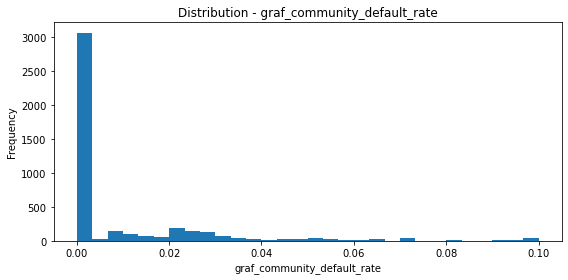

Feature     : graf_community_default_rate
Missing (%) : 0.00
Zero (%)    : 68.55
Median      : 0.0000
P99         : 0.1000
------------------------------------------------------------


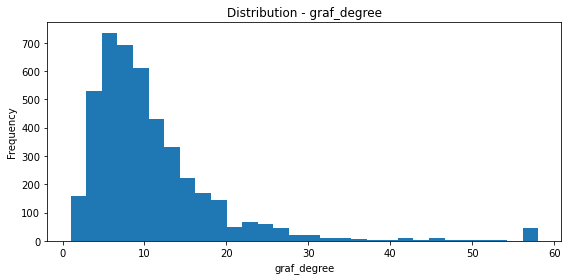

Feature     : graf_degree
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 9.0000
P99         : 58.0300
------------------------------------------------------------


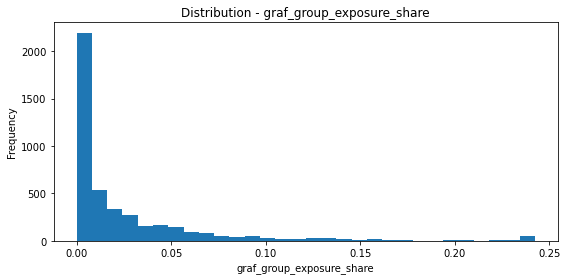

Feature     : graf_group_exposure_share
Missing (%) : 0.00
Zero (%)    : 34.72
Median      : 0.0081
P99         : 0.2423
------------------------------------------------------------


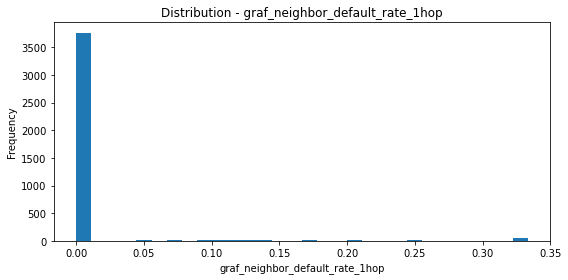

Feature     : graf_neighbor_default_rate_1hop
Missing (%) : 9.19
Zero (%)    : 94.70
Median      : 0.0000
P99         : 0.3333
------------------------------------------------------------


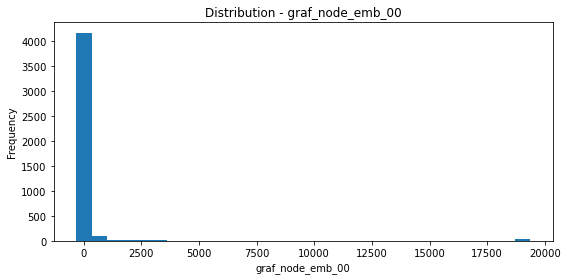

Feature     : graf_node_emb_00
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 19377.4155
------------------------------------------------------------


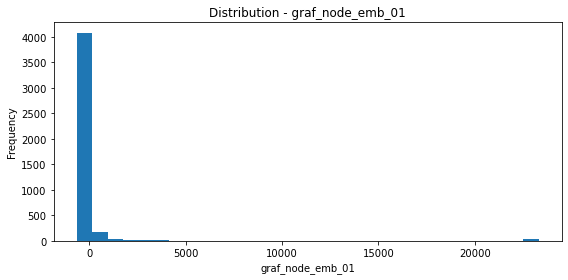

Feature     : graf_node_emb_01
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 23301.3908
------------------------------------------------------------


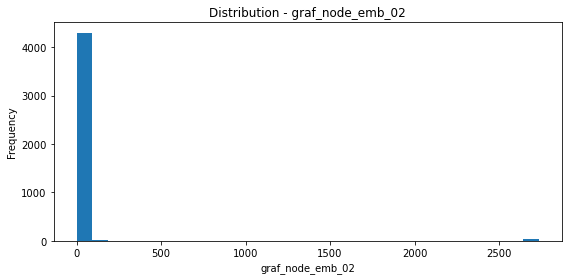

Feature     : graf_node_emb_02
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 2733.9414
------------------------------------------------------------


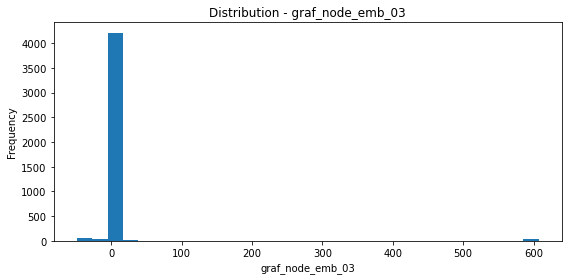

Feature     : graf_node_emb_03
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 607.0591
------------------------------------------------------------


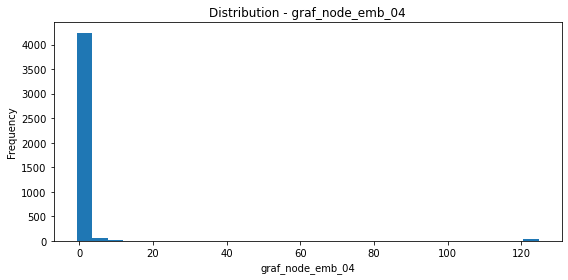

Feature     : graf_node_emb_04
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 124.6724
------------------------------------------------------------


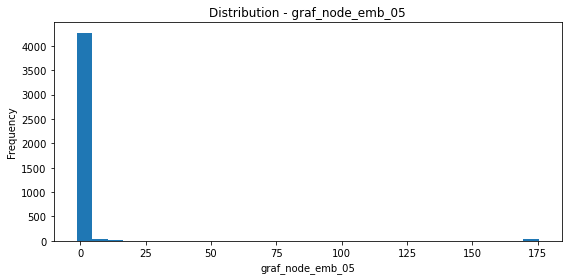

Feature     : graf_node_emb_05
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 175.3009
------------------------------------------------------------


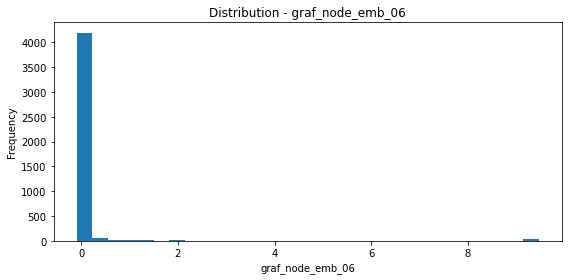

Feature     : graf_node_emb_06
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 9.4573
------------------------------------------------------------


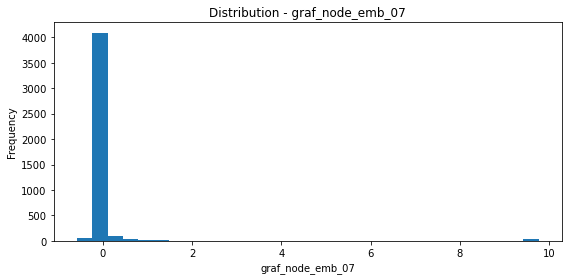

Feature     : graf_node_emb_07
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 9.7624
------------------------------------------------------------


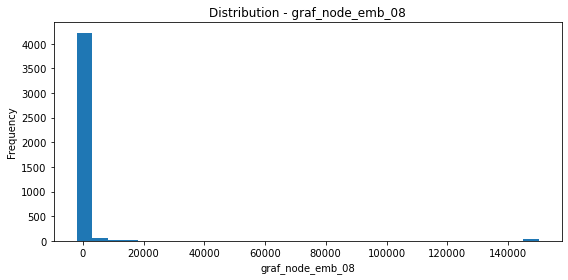

Feature     : graf_node_emb_08
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0002
P99         : 150043.2157
------------------------------------------------------------


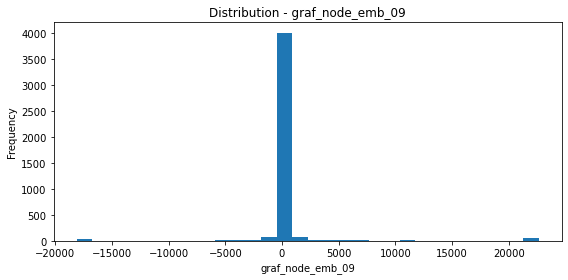

Feature     : graf_node_emb_09
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 22609.2255
------------------------------------------------------------


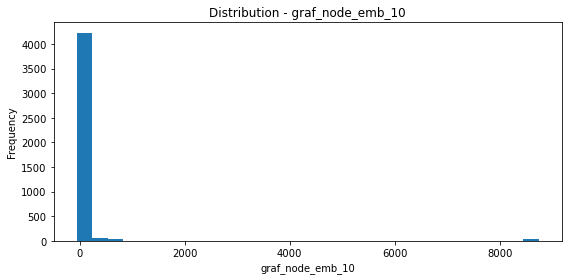

Feature     : graf_node_emb_10
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 8738.1031
------------------------------------------------------------


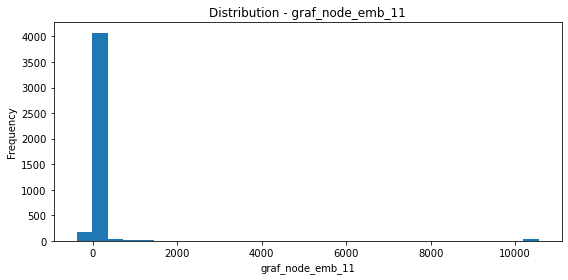

Feature     : graf_node_emb_11
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 0.0000
P99         : 10554.1124
------------------------------------------------------------


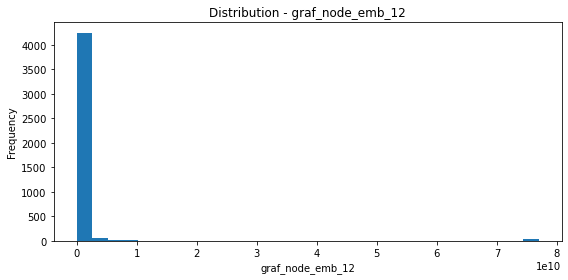

Feature     : graf_node_emb_12
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 1481.9320
P99         : 76935521744.0530
------------------------------------------------------------


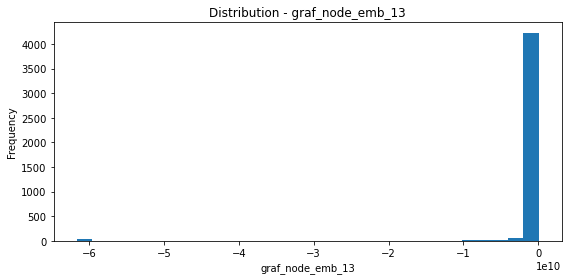

Feature     : graf_node_emb_13
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : -0.0000
P99         : 38880772.8920
------------------------------------------------------------


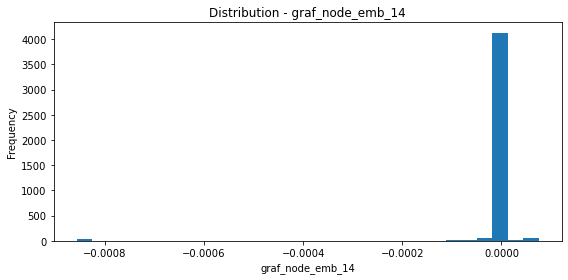

Feature     : graf_node_emb_14
Missing (%) : 0.00
Zero (%)    : 0.14
Median      : -0.0000
P99         : 0.0001
------------------------------------------------------------


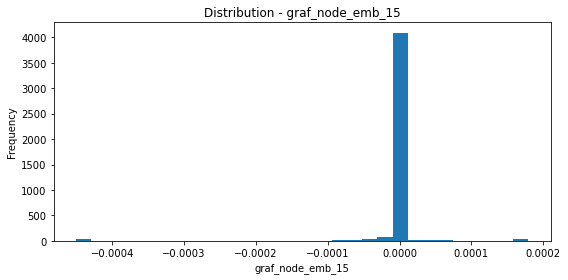

Feature     : graf_node_emb_15
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : -0.0000
P99         : 0.0002
------------------------------------------------------------


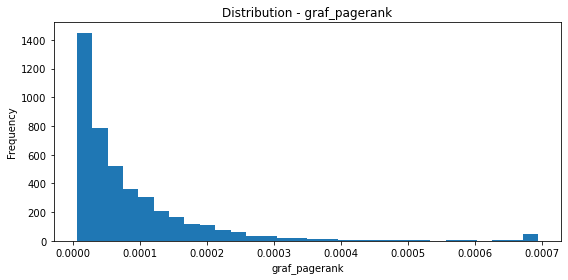

Feature     : graf_pagerank
Missing (%) : 0.00
Zero (%)    : 0.00
Median      : 0.0000
P99         : 0.0007
------------------------------------------------------------


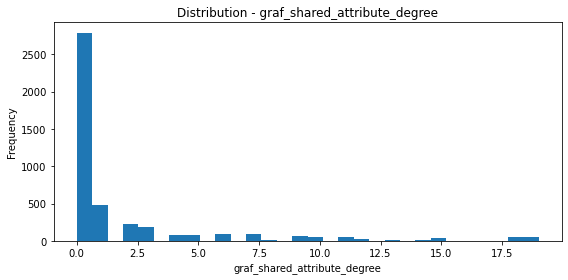

Feature     : graf_shared_attribute_degree
Missing (%) : 0.00
Zero (%)    : 63.39
Median      : 0.0000
P99         : 19.0000
------------------------------------------------------------


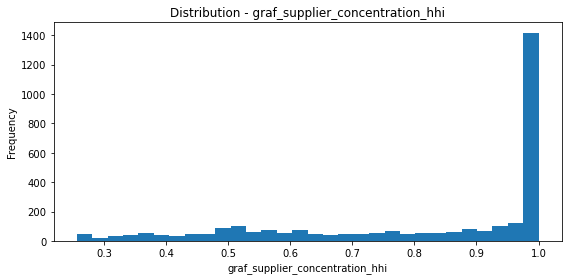

Feature     : graf_supplier_concentration_hhi
Missing (%) : 29.13
Zero (%)    : 29.13
Median      : 0.9478
P99         : 1.0000
------------------------------------------------------------


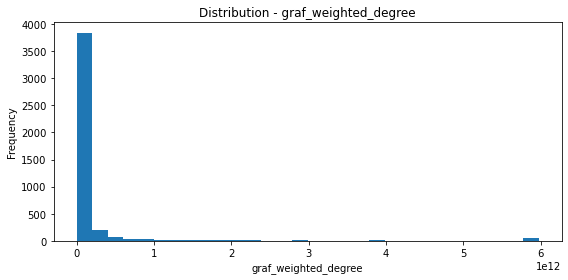

Feature     : graf_weighted_degree
Missing (%) : 0.00
Zero (%)    : 0.11
Median      : 4332121485.1627
P99         : 5971020673176.9844
------------------------------------------------------------


In [23]:
# ============================================================
# NUMERICAL GRAPH DISTRIBUTIONS
# ============================================================

for col in graph_numeric_cols:

    raw = pd.to_numeric(
        abt[col],
        errors="coerce"
    )

    s = raw.dropna()


    if s.empty:
        continue


    # hanya untuk visual supaya outlier tidak mendominasi chart
    lower = s.quantile(0.01)
    upper = s.quantile(0.99)


    plot_values = s.clip(
        lower=lower,
        upper=upper
    )


    plt.figure(
        figsize=(8, 4)
    )


    plt.hist(
        plot_values,
        bins=30
    )


    plt.title(
        f"Distribution - {col}"
    )

    plt.xlabel(
        col
    )

    plt.ylabel(
        "Frequency"
    )

    plt.tight_layout()

    plt.show()


    print(
        f"Feature     : {col}"
    )

    print(
        f"Missing (%) : "
        f"{raw.isna().mean()*100:.2f}"
    )

    print(
        f"Zero (%)    : "
        f"{(raw.fillna(0)==0).mean()*100:.2f}"
    )

    print(
        f"Median      : "
        f"{raw.median():.4f}"
    )

    print(
        f"P99         : "
        f"{raw.quantile(0.99):.4f}"
    )

    print(
        "-" * 60
    )

# Leakage audit — feature hasil keputusan

Dokumen handover mewajibkan drop:
- `app_keputusan`
- `app_pricing_bps`
- `app_komite_level`

Dari audit file aktual, ada tiga feature tambahan yang sebaiknya tidak digunakan untuk model **pre-decision**:

- `app_plafon_rp` = plafon final setelah proses approval
- `app_coverage_ratio` terbukti menggunakan plafon final
- `app_plafon_thd_penjualan` juga menggunakan plafon final

Kita tetap memakai `app_plafon_diminta_rp`, yaitu informasi yang tersedia ketika pengajuan masuk.

In [14]:
if {"app_plafon_diminta_rp", "app_plafon_rp"}.issubset(abt.columns):
    n_changed = (
        abt["app_plafon_diminta_rp"]
        != abt["app_plafon_rp"]
    ).sum()
    print("Requested vs final plafon berbeda:", n_changed)

if {
    "app_nilai_likuidasi_rp",
    "app_plafon_rp",
    "app_coverage_ratio",
}.issubset(abt.columns):
    reconstructed = (
        abt["app_nilai_likuidasi_rp"]
        / abt["app_plafon_rp"]
    )
    print(
        "Max abs error coverage ratio vs final plafon:",
        (reconstructed - abt["app_coverage_ratio"]).abs().max()
    )

if {
    "app_plafon_rp",
    "app_penjualan_rp",
    "app_plafon_thd_penjualan",
}.issubset(abt.columns):
    reconstructed = (
        abt["app_plafon_rp"]
        / abt["app_penjualan_rp"]
    )
    print(
        "Max abs error plafon/sales vs final plafon:",
        (reconstructed - abt["app_plafon_thd_penjualan"]).abs().max()
    )

Requested vs final plafon berbeda: 803
Max abs error coverage ratio vs final plafon: 4.99862170357801e-05
Max abs error plafon/sales vs final plafon: 0.0


# Missing Value Handling

In [15]:
def apply_semantic_rules(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # NaN debt/EBITDA adalah keadaan informatif: EBITDA <= 0
    if "fin_debt_to_ebitda" in out.columns:
        out["fin_ebitda_nonpositif"] = (
            out["fin_debt_to_ebitda"]
            .isna()
            .astype("int8")
        )

    # Untuk graph numerik, NaN berarti tidak ada relasi pada snapshot
    graph_numeric = [
        c for c in out.columns
        if c.startswith("graf_")
        and pd.api.types.is_numeric_dtype(out[c])
    ]

    if graph_numeric:
        out[graph_numeric] = out[graph_numeric].fillna(0)

    return out

abt = apply_semantic_rules(abt)

# Menentukan Feature Set 

In [16]:
POST_DECISION_APP_FEATURES = {
    "app_keputusan",
    "app_pricing_bps",
    "app_komite_level",
    "app_plafon_rp",
    "app_coverage_ratio",
    "app_plafon_thd_penjualan",
}

fin_cols = [
    c for c in abt.columns
    if c.startswith("fin_")
]

app_cols = [
    c for c in abt.columns
    if c.startswith("app_")
    and c not in POST_DECISION_APP_FEATURES
]

# community_id adalah label komunitas arbitrer, bukan magnitude risk
graf_cols = [
    c for c in abt.columns
    if c.startswith("graf_")
    and c != "graf_community_id"
]

baseline_cols = list(dict.fromkeys(fin_cols + app_cols))
graph_cols = list(dict.fromkeys(baseline_cols + graf_cols))

print("Financial features :", len(fin_cols))
print("Safe app features  :", len(app_cols))
print("Graph features     :", len(graf_cols))
print("Baseline total     :", len(baseline_cols))
print("+ Graph total      :", len(graph_cols))

for c in POST_DECISION_APP_FEATURES:
    assert c not in baseline_cols

assert "graf_community_id" not in graph_cols

Financial features : 30
Safe app features  : 17
Graph features     : 27
Baseline total     : 47
+ Graph total      : 74


# Buang Right Censored untuk Klasifikasi

In [17]:
labeled = abt.loc[abt[TARGET].notna()].copy()
labeled[TARGET] = labeled[TARGET].astype(int)

print("Labeled:", len(labeled))
print("Defaults:", labeled[TARGET].sum())
print("Bad rate:", labeled[TARGET].mean())

Labeled: 4049
Defaults: 129
Bad rate: 0.031859718448999756


# Population untuk Pemodelan

In [18]:
# ============================================================
# FINAL BASELINE POPULATION
# fin + app, TANPA graph
# ============================================================

train_all = labeled.loc[
    labeled["split"].eq("latih")
].copy()

oot_all = labeled.loc[
    labeled["split"].eq("uji_oot")
].copy()


X_train_all = train_all[
    baseline_cols
].copy()

y_train_all = train_all[
    TARGET
].astype(int).copy()


X_oot_all = oot_all[
    baseline_cols
].copy()

y_oot_all = oot_all[
    TARGET
].astype(int).copy()


groups_final = train_all[
    "grup_id"
].astype(str).copy()


print(
    "TRAIN:",
    len(train_all),
    "defaults:",
    y_train_all.sum()
)

print(
    "OOT:",
    len(oot_all),
    "defaults:",
    y_oot_all.sum()
)

TRAIN: 3670 defaults: 116
OOT: 379 defaults: 13


# Audit Group K Fold

In [19]:
from sklearn.model_selection import StratifiedGroupKFold

In [20]:
X_fold_all = train_all[baseline_cols]
y_train_all = train_all[TARGET].astype(int)
groups = train_all["grup_id"].astype(str)

gkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(
    gkf.split(X_fold_all, y_train_all, groups),
    start=1,
):
    y_tr = y_train_all.iloc[tr_idx]
    y_va = y_train_all.iloc[va_idx]

    train_groups = set(groups.iloc[tr_idx])
    valid_groups = set(groups.iloc[va_idx])

    fold_rows.append({
        "fold": fold,
        "train_n": len(tr_idx),
        "train_events": int(y_tr.sum()),
        "valid_n": len(va_idx),
        "valid_events": int(y_va.sum()),
        "valid_bad_rate": float(y_va.mean()),
        "overlap_group": len(train_groups & valid_groups),
    })

fold_audit = pd.DataFrame(fold_rows)
display(fold_audit)

assert (fold_audit["valid_events"] > 0).all()
assert (fold_audit["overlap_group"] == 0).all()

,fold,train_n,train_events,valid_n,valid_events,valid_bad_rate,overlap_group
0,1,2989,93,681,23,0.033774,0
1,2,2915,94,755,22,0.029139,0
2,3,2956,87,714,29,0.040616,0
3,4,2949,93,721,23,0.031900,0
4,5,2871,97,799,19,0.023780,0


# Preprocessor

In [21]:
def build_preprocessor(X: pd.DataFrame):
    numeric_cols = X.select_dtypes(
        include=["number", "bool"]
    ).columns.tolist()

    categorical_cols = [
        c for c in X.columns
        if c not in numeric_cols
    ]

    num_pipe = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        (
            "scaler",
            StandardScaler(with_mean=False),
        ),
    ])

    cat_pipe = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ])

    return ColumnTransformer([
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),
    ])

# Evaluation Helper

In [22]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef
)


# ============================================================
# KS STATISTIC
# ============================================================

def ks_statistic(y_true, p):
    fpr, tpr, _ = roc_curve(y_true, p)
    return float(np.max(tpr - fpr))


# ============================================================
# BINARY CLASSIFICATION EVALUATION
# ============================================================

def evaluate_binary(y_true, p, name, threshold=0.5):

    # --------------------------------------------------------
    # Prepare data
    # --------------------------------------------------------
    y_true = np.asarray(y_true).astype(int)
    p = np.clip(np.asarray(p), 1e-7, 1 - 1e-7)

    # Convert probability -> class
    y_pred = (p >= threshold).astype(int)

    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # --------------------------------------------------------
    # Threshold-independent metrics
    # --------------------------------------------------------
    auc = roc_auc_score(y_true, p)

    gini = 2 * auc - 1

    pr_auc = average_precision_score(
        y_true,
        p
    )

    ks = ks_statistic(
        y_true,
        p
    )

    brier = brier_score_loss(
        y_true,
        p
    )

    ll = log_loss(
        y_true,
        p
    )

    # --------------------------------------------------------
    # Threshold-dependent metrics
    # --------------------------------------------------------
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f2 = fbeta_score(
        y_true,
        y_pred,
        beta=2,
        zero_division=0
    )

    # Specificity = True Negative Rate
    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    # Negative Predictive Value
    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    # False Positive Rate
    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    # False Negative Rate
    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else np.nan
    )

    # Alert rate / predicted bad rate
    alert_rate = y_pred.mean()

    # Matthews Correlation Coefficient
    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------
    return pd.DataFrame([{

        # Model info
        "model": name,
        "threshold": threshold,

        # Population
        "n": len(y_true),
        "events": int(y_true.sum()),
        "non_events": int(len(y_true) - y_true.sum()),
        "bad_rate": y_true.mean(),

        # Discrimination
        "roc_auc": auc,
        "gini": gini,
        "pr_auc": pr_auc,
        "ks": ks,

        # Calibration
        "brier": brier,
        "log_loss": ll,

        # Confusion Matrix
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,

        # Classification performance
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "npv": npv,
        "f1": f1,
        "f2": f2,
        "mcc": mcc,

        # Error rates
        "fpr": fpr,
        "fnr": fnr,

        # Operational
        "alert_rate": alert_rate,

    }])

# Candidate models

Kita bandingkan:
- Logistic Regression
- XGBoost

OOT **belum** dipakai untuk memilih hyperparameter.

In [24]:
n_pos = int(y_train_all.sum())
n_neg = int((y_train_all == 0).sum())
scale_pos_weight = n_neg / n_pos

def make_logit(feature_cols):
    return Pipeline([
        ("preprocess", build_preprocessor(train_all[feature_cols])),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="liblinear",
                random_state=SEED,
            ),
        ),
    ])


def make_xgb(feature_cols, **extra):
    params = dict(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=350,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=2.0,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        n_jobs=1,
    )
    params.update(extra)

    return Pipeline([
        ("preprocess", build_preprocessor(train_all[feature_cols])),
        ("model", XGBClassifier(**params)),
    ])

# Group Aware CV - model family

In [26]:
import numpy as np
import pandas as pd

from sklearn.base import clone


# ============================================================
# CANDIDATE MODELS
# ============================================================

candidate_models = {
    "logit_baseline": (
        make_logit(baseline_cols),
        baseline_cols,
    ),
    "xgb_baseline": (
        make_xgb(baseline_cols),
        baseline_cols,
    ),
}


# ============================================================
# EVALUATION THRESHOLD
# ============================================================
# Untuk sementara bisa 0.5.
# Kalau nanti sudah punya threshold hasil tuning,
# ganti dengan threshold tersebut.

EVAL_THRESHOLD = 0.50


# ============================================================
# CONTAINER
# ============================================================

fold_results = []
oof_results = []
oof_predictions = {}


# ============================================================
# CROSS VALIDATION + OOF EVALUATION
# ============================================================

for name, (model, cols) in candidate_models.items():

    print("=" * 70)
    print(f"Evaluating: {name}")
    print("=" * 70)

    X = train_all[cols].copy()
    y = np.asarray(y_train_all).astype(int)
    group_array = np.asarray(groups)

    # Tempat menyimpan probabilitas OOF
    oof_p = np.full(len(y), np.nan)

    # --------------------------------------------------------
    # Loop CV
    # --------------------------------------------------------
    for fold, (train_idx, valid_idx) in enumerate(
        gkf.split(
            X,
            y,
            groups=group_array
        ),
        start=1
    ):

        # Clone model supaya setiap fold modelnya fresh
        fold_model = clone(model)

        X_tr = X.iloc[train_idx]
        X_val = X.iloc[valid_idx]

        y_tr = y[train_idx]
        y_val = y[valid_idx]

        # Fit
        fold_model.fit(
            X_tr,
            y_tr
        )

        # Predict probability
        p_val = fold_model.predict_proba(
            X_val
        )[:, 1]

        # Simpan OOF probability
        oof_p[valid_idx] = p_val

        # ----------------------------------------------------
        # Evaluate per fold
        # ----------------------------------------------------
        fold_eval = evaluate_binary(
            y_true=y_val,
            p=p_val,
            name=name,
            threshold=EVAL_THRESHOLD
        )

        fold_eval["fold"] = fold

        fold_results.append(
            fold_eval
        )

    # --------------------------------------------------------
    # Check OOF complete
    # --------------------------------------------------------
    assert not np.isnan(oof_p).any(), \
        f"Ada OOF prediction yang kosong pada model {name}"

    # Simpan OOF probability
    oof_predictions[name] = oof_p

    # --------------------------------------------------------
    # Overall OOF Evaluation
    # --------------------------------------------------------
    oof_eval = evaluate_binary(
        y_true=y,
        p=oof_p,
        name=name,
        threshold=EVAL_THRESHOLD
    )

    oof_eval["evaluation"] = "OOF"

    oof_results.append(
        oof_eval
    )


# ============================================================
# CONCAT RESULTS
# ============================================================

fold_result = pd.concat(
    fold_results,
    ignore_index=True
)

oof_result = pd.concat(
    oof_results,
    ignore_index=True
)

Evaluating: logit_baseline
Evaluating: xgb_baseline


In [27]:
# ============================================================
# CV SUMMARY
# ============================================================

cv_metrics = [
    # Discrimination
    "roc_auc",
    "gini",
    "pr_auc",
    "ks",

    # Calibration
    "brier",
    "log_loss",

    # Classification
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "npv",
    "f1",
    "f2",
    "mcc",

    # Error / Operational
    "fpr",
    "fnr",
    "alert_rate",
]


cv_summary = (
    fold_result
    .groupby("model")[cv_metrics]
    .agg(["mean", "std"])
)


# Flatten column names
cv_summary.columns = [
    f"{metric}_{stat}"
    for metric, stat in cv_summary.columns
]

cv_summary = (
    cv_summary
    .reset_index()
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
)

display(cv_summary)

,model,roc_auc_mean,roc_auc_std,gini_mean,gini_std,pr_auc_mean,pr_auc_std,ks_mean,ks_std,brier_mean,brier_std,log_loss_mean,log_loss_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,specificity_mean,specificity_std,npv_mean,npv_std,f1_mean,f1_std,f2_mean,f2_std,mcc_mean,mcc_std,fpr_mean,fpr_std,fnr_mean,fnr_std,alert_rate_mean,alert_rate_std
1,xgb_baseline,0.850607,0.037017,0.701215,0.074034,0.226755,0.07441,0.594893,0.074646,0.057265,0.002021,0.189988,0.006883,0.922667,0.004548,0.704644,0.071690,0.197819,0.068983,0.471953,0.144638,0.937336,0.005855,0.982014,0.005028,0.276422,0.087813,0.365989,0.110043,0.270005,0.094908,0.062664,0.005855,0.528047,0.144638,0.075883,0.007695
0,logit_baseline,0.825212,0.048378,0.650425,0.096755,0.182617,0.04521,0.556348,0.100882,0.132536,0.007858,0.425218,0.020444,0.812731,0.015969,0.736555,0.061674,0.108250,0.034995,0.655593,0.114410,0.817516,0.015303,0.986840,0.002746,0.185112,0.055978,0.323478,0.085702,0.211425,0.067372,0.182484,0.015303,0.344407,0.114410,0.198004,0.012615


In [28]:
# ============================================================
# OVERALL OOF EVALUATION
# ============================================================

oof_cols = [
    "model",
    "threshold",

    # Population
    "n",
    "events",
    "non_events",
    "bad_rate",

    # Discrimination
    "roc_auc",
    "gini",
    "pr_auc",
    "ks",

    # Calibration
    "brier",
    "log_loss",

    # Confusion Matrix
    "TP",
    "FP",
    "TN",
    "FN",

    # Classification
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "npv",
    "f1",
    "f2",
    "mcc",

    # Error Rates
    "fpr",
    "fnr",

    # Operational
    "alert_rate",
]


oof_result_display = (
    oof_result[oof_cols]
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(oof_result_display)

,model,threshold,n,events,non_events,bad_rate,roc_auc,gini,pr_auc,ks,brier,log_loss,TP,FP,TN,FN,accuracy,balanced_accuracy,precision,recall,specificity,npv,f1,f2,mcc,fpr,fnr,alert_rate
0,xgb_baseline,0.5,3670,116,3554,0.031608,0.850001,0.700003,0.205113,0.551608,0.057322,0.190221,55,223,3331,61,0.922616,0.705696,0.197842,0.474138,0.937254,0.982017,0.279188,0.370620,0.272015,0.062746,0.525862,0.075749
1,logit_baseline,0.5,3670,116,3554,0.031608,0.828896,0.657792,0.158268,0.530810,0.132812,0.425937,77,650,2904,39,0.812262,0.740450,0.105915,0.663793,0.817107,0.986748,0.182681,0.323258,0.211096,0.182893,0.336207,0.198093


In [29]:
display(
    oof_result_display.set_index("model").T
)

model,xgb_baseline,logit_baseline
threshold,0.500000,0.500000
n,3670.000000,3670.000000
events,116.000000,116.000000
non_events,3554.000000,3554.000000
bad_rate,0.031608,0.031608
roc_auc,0.850001,0.828896
gini,0.700003,0.657792
pr_auc,0.205113,0.158268
ks,0.551608,0.530810
brier,0.057322,0.132812


# Hyperparameter tuning XGBoost — TRAIN only

Search berikut dilakukan dengan GroupKFold yang sama.
OOT tidak dilihat selama tuning.

In [30]:
# ============================================================
# HYPERPARAMETER TUNING
# Optimasi utama: PR-AUC
# Tetap evaluasi: ROC-AUC + PR-AUC
# ============================================================

RUN_TUNING = True

base_xgb = make_xgb(baseline_cols)

param_dist = {
    "model__n_estimators": [200, 300, 450, 600, 800],
    "model__learning_rate": [0.015, 0.02, 0.03, 0.05],
    "model__max_depth": [2, 3, 4],
    "model__min_child_weight": [3, 5, 8, 12],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__reg_alpha": [0.0, 0.1, 0.3, 0.8],
    "model__reg_lambda": [1.0, 2.0, 5.0, 10.0],
        "model__scale_pos_weight": [
        1,
        3,
        5,
        8,
        10,
        15,
        20,
        30
    ],

    "model__max_delta_step": [
        0,
        1,
        3
    ],
}


if RUN_TUNING:

    # ========================================================
    # MULTI-METRIC SCORING
    # ========================================================

    scoring = {
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
    }


    tuner = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_dist,

        n_iter=40,

        # Evaluasi dua metric sekaligus
        scoring=scoring,

        cv=gkf,
        random_state=SEED,
        n_jobs=-1,

        # Model terbaik dipilih berdasarkan PR-AUC
        refit="pr_auc",

        verbose=1,
        return_train_score=False,
    )


    # ========================================================
    # FIT TUNER
    # ========================================================

    tuner.fit(
        X_train_all,
        y_train_all,
        groups=groups
    )


    # ========================================================
    # BEST MODEL
    # ========================================================

    champion_candidate = tuner.best_estimator_


    # ========================================================
    # AMBIL INDEX MODEL TERBAIK
    # ========================================================

    best_idx = tuner.best_index_


    # ========================================================
    # AMBIL METRIC CV MODEL TERBAIK
    # ========================================================

    best_cv_roc_auc_mean = (
        tuner.cv_results_[
            "mean_test_roc_auc"
        ][best_idx]
    )

    best_cv_roc_auc_std = (
        tuner.cv_results_[
            "std_test_roc_auc"
        ][best_idx]
    )

    best_cv_pr_auc_mean = (
        tuner.cv_results_[
            "mean_test_pr_auc"
        ][best_idx]
    )

    best_cv_pr_auc_std = (
        tuner.cv_results_[
            "std_test_pr_auc"
        ][best_idx]
    )


    # ========================================================
    # PRINT RESULT
    # ========================================================

    print("=" * 60)
    print("BEST MODEL - CROSS VALIDATION RESULT")
    print("=" * 60)

    print(
        f"CV ROC-AUC Mean : "
        f"{best_cv_roc_auc_mean:.4f}"
    )

    print(
        f"CV ROC-AUC Std  : "
        f"{best_cv_roc_auc_std:.4f}"
    )

    print()

    print(
        f"CV PR-AUC Mean  : "
        f"{best_cv_pr_auc_mean:.4f}"
    )

    print(
        f"CV PR-AUC Std   : "
        f"{best_cv_pr_auc_std:.4f}"
    )

    print()

    print("Best Parameters:")
    print(tuner.best_params_)


else:

    champion_candidate = make_xgb(
        baseline_cols,
        n_estimators=450,
        learning_rate=0.02,
        max_depth=3,
        min_child_weight=8,
        subsample=0.7,
        colsample_bytree=1.0,
        reg_alpha=0.3,
        reg_lambda=1.0,
    )

Fitting 5 folds for each of 40 candidates, totalling 200 fits
BEST MODEL - CROSS VALIDATION RESULT
CV ROC-AUC Mean : 0.8692
CV ROC-AUC Std  : 0.0235

CV PR-AUC Mean  : 0.2532
CV PR-AUC Std   : 0.0818

Best Parameters:
{'model__subsample': 0.85, 'model__scale_pos_weight': 20, 'model__reg_lambda': 10.0, 'model__reg_alpha': 0.0, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__max_delta_step': 1, 'model__learning_rate': 0.02, 'model__colsample_bytree': 1.0}


# OOT evaluation — tuned baseline

In [31]:
y_oot = oot_all[TARGET].astype(int)

champion_candidate.fit(
    train_all[baseline_cols],
    y_train_all,
)

p_baseline_oot = champion_candidate.predict_proba(
    oot_all[baseline_cols]
)[:, 1]


display(
    evaluate_binary(
        y_oot,
        p_baseline_oot,
        "XGB baseline tuned",
    )
)

,model,threshold,n,events,non_events,bad_rate,roc_auc,gini,pr_auc,ks,brier,log_loss,TP,FP,TN,FN,accuracy,balanced_accuracy,precision,recall,specificity,npv,f1,f2,mcc,fpr,fnr,alert_rate
0,XGB baseline tuned,0.5,379,13,366,0.034301,0.786045,0.572089,0.131332,0.529214,0.088921,0.286577,5,44,322,8,0.862797,0.632198,0.102041,0.384615,0.879781,0.975758,0.16129,0.247525,0.143421,0.120219,0.615385,0.129288


# Population untuk eksperimen Graph

In [35]:
book_new = labeled.loc[
    labeled["angkatan"].eq("buku_baru")
].copy()

train_graph = book_new.loc[
    book_new["split"].eq("latih")
].copy()

oot_graph = book_new.loc[
    book_new["split"].eq("uji_oot")
].copy()

print("TRAIN:", len(train_graph), "events:", train_graph[TARGET].sum())
print("OOT  :", len(oot_graph), "events:", oot_graph[TARGET].sum())

assert len(train_graph) == 1681
assert int(train_graph[TARGET].sum()) == 53
assert len(oot_graph) == 395
assert int(oot_graph[TARGET].sum()) == 14

TRAIN: 1589 events: 51
OOT  : 379 events: 13


AssertionError: 

## Strict Graph Ablation

Agar fair:
- algorithm sama
- train rows sama
- OOT rows sama
- target sama
- graph model hanya menambahkan `graf_*`

`graf_community_id` tidak dipakai karena hanya label komunitas arbitrer.

In [36]:
y_train_graph = train_graph[TARGET].astype(int)
y_oot_graph = oot_graph[TARGET].astype(int)

In [37]:
# ============================================================
# ABLATION TEST
# BASELINE vs BASELINE + GRAPH
#
# TRAIN  = 5-FOLD CROSS VALIDATION
# TEST   = OOT
# ============================================================

from sklearn.model_selection import cross_validate


# ============================================================
# 1. AMBIL BEST HYPERPARAMETER DARI TUNER
# ============================================================

best_params = {
    key.replace("model__", ""): value
    for key, value in tuner.best_params_.items()
}

print("Best Hyperparameters:")
print(best_params)


# ============================================================
# 2. BUAT MODEL
# Hyperparameter dibuat sama agar ablation fair
# ============================================================

baseline_tuned_model = make_xgb(
    baseline_cols,
    **best_params
)

graph_tuned_model = make_xgb(
    graph_cols,
    **best_params
)


# ============================================================
# 3. GROUP UNTUK CV
# ============================================================

groups_graph = (
    train_graph["grup_id"]
    .astype(str)
    .copy()
)


# ============================================================
# 4. BUAT CV SPLIT SEKALI
# Baseline & graph pakai fold yang sama
# ============================================================

cv_splits_graph = list(
    gkf.split(
        train_graph[baseline_cols],
        y_train_graph,
        groups=groups_graph
    )
)


# ============================================================
# 5. METRIC CV
# ============================================================

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}


# ============================================================
# 6. TRAIN EVALUATION - BASELINE
# PAKAI CROSS VALIDATION
# ============================================================

cv_baseline = cross_validate(
    baseline_tuned_model,

    train_graph[baseline_cols],
    y_train_graph,

    groups=groups_graph,
    cv=cv_splits_graph,

    scoring=scoring,

    n_jobs=-1,
    return_train_score=False,
)


# ============================================================
# 7. TRAIN EVALUATION - GRAPH
# PAKAI CROSS VALIDATION
# ============================================================

cv_graph = cross_validate(
    graph_tuned_model,

    train_graph[graph_cols],
    y_train_graph,

    groups=groups_graph,
    cv=cv_splits_graph,

    scoring=scoring,

    n_jobs=-1,
    return_train_score=False,
)


# ============================================================
# 8. SUMMARY TRAIN / CV
# ============================================================

train_cv_result = pd.DataFrame({

    "dataset": [
        "TRAIN - CV",
        "TRAIN - CV"
    ],

    "model": [
        "Baseline fin + app",
        "Baseline + graph"
    ],

    "roc_auc": [
        cv_baseline["test_roc_auc"].mean(),
        cv_graph["test_roc_auc"].mean()
    ],

    "roc_auc_std": [
        cv_baseline["test_roc_auc"].std(),
        cv_graph["test_roc_auc"].std()
    ],

    "pr_auc": [
        cv_baseline["test_pr_auc"].mean(),
        cv_graph["test_pr_auc"].mean()
    ],

    "pr_auc_std": [
        cv_baseline["test_pr_auc"].std(),
        cv_graph["test_pr_auc"].std()
    ],
})


# ============================================================
# 9. REFIT BASELINE PADA SELURUH TRAIN
# ============================================================

baseline_tuned_model.fit(
    train_graph[baseline_cols],
    y_train_graph
)


# ============================================================
# 10. REFIT GRAPH PADA SELURUH TRAIN
# ============================================================

graph_tuned_model.fit(
    train_graph[graph_cols],
    y_train_graph
)


# ============================================================
# 11. PREDICT TEST / OOT - BASELINE
# ============================================================

p_baseline_oot = (
    baseline_tuned_model
    .predict_proba(
        oot_graph[baseline_cols]
    )[:, 1]
)


# ============================================================
# 12. PREDICT TEST / OOT - GRAPH
# ============================================================

p_graph_oot = (
    graph_tuned_model
    .predict_proba(
        oot_graph[graph_cols]
    )[:, 1]
)


# ============================================================
# 13. TEST / OOT EVALUATION
# ============================================================

test_result = pd.concat(
    [
        evaluate_binary(
            y_oot_graph,
            p_baseline_oot,
            "Baseline fin + app",
        ),

        evaluate_binary(
            y_oot_graph,
            p_graph_oot,
            "Baseline + graph",
        ),
    ],
    ignore_index=True,
)

test_result["dataset"] = "TEST - OOT"


# ============================================================
# 14. AMBIL KOLOM TEST YANG RELEVAN
# ============================================================

test_summary = test_result[
    [
        "dataset",
        "model",
        "roc_auc",
        "pr_auc",
    ]
].copy()

# karena TEST cuma sekali,
# tidak ada std cross-validation
test_summary["roc_auc_std"] = np.nan
test_summary["pr_auc_std"] = np.nan


# ============================================================
# 15. GABUNGKAN TRAIN CV + TEST OOT
# ============================================================

final_ablation_result = pd.concat(
    [
        train_cv_result,
        test_summary
    ],
    ignore_index=True,
)


# susun urutan kolom
final_ablation_result = final_ablation_result[
    [
        "dataset",
        "model",
        "roc_auc",
        "roc_auc_std",
        "pr_auc",
        "pr_auc_std",
    ]
]


display(final_ablation_result)

Best Hyperparameters:
{'subsample': 0.85, 'scale_pos_weight': 20, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'max_delta_step': 1, 'learning_rate': 0.02, 'colsample_bytree': 1.0}


,dataset,model,roc_auc,roc_auc_std,pr_auc,pr_auc_std
0,TRAIN - CV,Baseline fin + app,0.831609,0.056446,0.212788,0.097684
1,TRAIN - CV,Baseline + graph,0.819671,0.068286,0.202407,0.085571
2,TEST - OOT,Baseline fin + app,0.765448,NaN,0.128798,NaN
3,TEST - OOT,Baseline + graph,0.759983,NaN,0.123373,NaN


# Bootstrap 95% CI untuk delta AUC graph

In [38]:
def paired_stratified_bootstrap_auc(
    y_true,
    p_base,
    p_graph,
    n_boot=5000,
    seed=42,
):
    y = np.asarray(y_true).astype(int)
    p0 = np.asarray(p_base)
    p1 = np.asarray(p_graph)

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    rng = np.random.default_rng(seed)
    diffs = []

    for _ in range(n_boot):
        sample_pos = rng.choice(
            pos_idx,
            size=len(pos_idx),
            replace=True,
        )
        sample_neg = rng.choice(
            neg_idx,
            size=len(neg_idx),
            replace=True,
        )

        idx = np.concatenate([
            sample_pos,
            sample_neg,
        ])

        auc_base = roc_auc_score(
            y[idx],
            p0[idx],
        )
        auc_graph = roc_auc_score(
            y[idx],
            p1[idx],
        )

        diffs.append(
            auc_graph - auc_base
        )

    diffs = np.asarray(diffs)

    return pd.DataFrame([{
        "delta_auc": (
            roc_auc_score(y, p1)
            - roc_auc_score(y, p0)
        ),
        "ci_low_95": np.quantile(diffs, 0.025),
        "ci_high_95": np.quantile(diffs, 0.975),
    }])


graph_delta = paired_stratified_bootstrap_auc(
    y_oot_graph,
    p_baseline_oot,
    p_graph_oot,
)

display(graph_delta)

,delta_auc,ci_low_95,ci_high_95
0,-0.005464,-0.037411,0.025221


### Interpretasi ablation

- Jika seluruh CI delta AUC > 0 → ada evidence graph meningkatkan discrimination.
- Jika CI melintasi 0 → jangan klaim uplift model; gunakan graph sebagai risk overlay / diagnostic signal.

Pada OOT sample, model dengan graph menghasilkan AUC sekitar 0.019 lebih rendah dari baseline. Namun confidence interval 95% (-0.064 sampai +0.019) mencakup nol, sehingga perbedaan tersebut belum signifikan secara statistik.

# Business Signal Graph

In [39]:
signal_tables = []

for col in [
    "graf_neighbor_default_rate_1hop",
    "graf_community_default_rate",
]:
    if col not in book_new.columns:
        continue

    tmp = book_new[[col, TARGET]].copy()
    tmp["has_historical_signal"] = (
        tmp[col].fillna(0) > 0
    )

    stat = (
        tmp.groupby("has_historical_signal")
           .agg(
               n=(TARGET, "size"),
               defaults=(TARGET, "sum"),
               bad_rate=(TARGET, "mean"),
           )
           .reset_index()
    )

    stat["feature"] = col
    stat["bad_rate_pct"] = 100 * stat["bad_rate"]
    signal_tables.append(stat)

graph_signal = pd.concat(
    signal_tables,
    ignore_index=True,
)

display(graph_signal)

,has_historical_signal,n,defaults,bad_rate,feature,bad_rate_pct
0,False,1778,51,0.028684,graf_neighbor_default_rate_1hop,2.868391
1,True,190,13,0.068421,graf_neighbor_default_rate_1hop,6.842105
2,False,263,4,0.015209,graf_community_default_rate,1.520913
3,True,1705,60,0.035191,graf_community_default_rate,3.519062


Debitur yang punya tetangga langsung (1-hop) dengan riwayat default memiliki bad rate 6,37%, sedangkan yang tidak punya hanya 2,88%.
6.37 / 2.88 ≈ 2.2x
Ada historical default pada direct neighbor → risiko default sekitar 2,2 kali lebih tinggi.

Kalau komunitas graph debitur memiliki historical default, bad rate naik dari 2,96% menjadi 3,51%.
3.51 / 2.96 ≈ 1.19x
Jadi hanya sekitar 19% lebih tinggi.

Direct network exposure terhadap pihak yang sudah default jauh lebih informative dibanding sekadar berada dalam komunitas yang memiliki historical default.


# OOF calibration — Platt scaling

PD adalah probabilitas, jadi kita perlu mengevaluasi calibration.
Calibrator dilatih dari **out-of-fold prediction training**, bukan OOT.

In [40]:
def group_oof_probability(
    model,
    X,
    y,
    groups,
    cv,
):
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    groups = groups.reset_index(drop=True)

    oof = np.full(len(X), np.nan)

    for tr_idx, va_idx in cv.split(
        X,
        y,
        groups,
    ):
        m = clone(model)

        m.fit(
            X.iloc[tr_idx],
            y.iloc[tr_idx],
        )

        oof[va_idx] = m.predict_proba(
            X.iloc[va_idx]
        )[:, 1]

    assert not np.isnan(oof).any()
    return oof


oof_raw = group_oof_probability(
    champion_candidate,
    train_all[baseline_cols],
    y_train_all,
    groups,
    gkf,
)

oof_logit = logit(
    np.clip(
        oof_raw,
        1e-6,
        1 - 1e-6,
    )
).reshape(-1, 1)

calibrator = LogisticRegression(
    solver="lbfgs"
)

calibrator.fit(
    oof_logit,
    y_train_all,
)

oof_calibrated = calibrator.predict_proba(
    oof_logit
)[:, 1]

display(pd.concat([
    evaluate_binary(
        y_train_all,
        oof_raw,
        "OOF raw",
    ),
    evaluate_binary(
        y_train_all,
        oof_calibrated,
        "OOF calibrated",
    ),
], ignore_index=True))

,model,threshold,n,events,non_events,bad_rate,roc_auc,gini,pr_auc,ks,brier,log_loss,TP,FP,TN,FN,accuracy,balanced_accuracy,precision,recall,specificity,npv,f1,f2,mcc,fpr,fnr,alert_rate
0,OOF raw,0.5,3670,116,3554,0.031608,0.868997,0.737993,0.21038,0.614,0.073239,0.246846,65,338,3216,51,0.894005,0.73262,0.16129,0.560345,0.904896,0.984389,0.250482,0.374856,0.260338,0.095104,0.439655,0.109809
1,OOF calibrated,0.5,3670,116,3554,0.031608,0.868997,0.737993,0.21038,0.614,0.027290,0.107687,0,0,3554,116,0.968392,0.50000,0.00000,0.000000,1.000000,0.968392,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


Calibration mempertahankan kemampuan model dalam meranking risiko, yang terlihat dari ROC-AUC dan PR-AUC yang tidak berubah, namun meningkatkan kualitas probabilitas prediksi secara signifikan, ditunjukkan oleh penurunan Brier Score dan Log Loss.

# Apply calibrator ke OOT

In [41]:
champion_candidate.fit(
    train_all[baseline_cols],
    y_train_all,
)

p_oot_raw = champion_candidate.predict_proba(
    oot_all[baseline_cols]
)[:, 1]

p_oot_cal = calibrator.predict_proba(
    logit(
        np.clip(
            p_oot_raw,
            1e-6,
            1 - 1e-6,
        )
    ).reshape(-1, 1)
)[:, 1]

calibration_result = pd.concat([
    evaluate_binary(
        y_oot_all,
        p_oot_raw,
        "OOT raw",
    ),
    evaluate_binary(
        y_oot_all,
        p_oot_cal,
        "OOT calibrated",
    ),
], ignore_index=True)

display(calibration_result)

,model,threshold,n,events,non_events,bad_rate,roc_auc,gini,pr_auc,ks,brier,log_loss,TP,FP,TN,FN,accuracy,balanced_accuracy,precision,recall,specificity,npv,f1,f2,mcc,fpr,fnr,alert_rate
0,OOT raw,0.5,379,13,366,0.034301,0.786045,0.572089,0.131332,0.529214,0.088921,0.286577,5,44,322,8,0.862797,0.632198,0.102041,0.384615,0.879781,0.975758,0.16129,0.247525,0.143421,0.120219,0.615385,0.129288
1,OOT calibrated,0.5,379,13,366,0.034301,0.786045,0.572089,0.131332,0.529214,0.032464,0.135378,0,0,366,13,0.965699,0.500000,0.000000,0.000000,1.000000,0.965699,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000


Model mempertahankan ROC-AUC 0.788 dan PR-AUC 0.123 setelah calibration, sementara Brier Score turun dari 0.0418 menjadi 0.0332 dan Log Loss turun dari 0.157 menjadi 0.136. Ini menunjukkan calibration memperbaiki reliability dari predicted PD tanpa mengubah ranking risiko.

# Confusion Matrix

In [59]:
# ============================================================
# THRESHOLD OPTIMIZATION — PRIORITAS RECALL
# Threshold dipilih dari TRAIN OOF, BUKAN dari OOT
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    fbeta_score
)

# ------------------------------------------------------------
# 1. TARGET RECALL
# ------------------------------------------------------------

TARGET_RECALL = 0.80
# Kalau ingin lebih agresif:
# TARGET_RECALL = 0.80


# ------------------------------------------------------------
# 2. CARI THRESHOLD DARI TRAIN OOF
# ------------------------------------------------------------

precision_oof, recall_oof, thresholds_oof = precision_recall_curve(
    y_train_all,
    oof_raw
)

threshold_table = pd.DataFrame({
    "threshold": thresholds_oof,
    "precision": precision_oof[:-1],
    "recall": recall_oof[:-1],
})


# Ambil threshold yang memenuhi target recall
eligible = threshold_table[
    threshold_table["recall"] >= TARGET_RECALL
].copy()


if len(eligible) == 0:
    raise ValueError(
        f"Tidak ada threshold yang menghasilkan recall >= {TARGET_RECALL:.0%}"
    )


# Dari semua threshold yang memenuhi target recall,
# pilih yang precision-nya paling tinggi.
best_threshold_row = (
    eligible
    .sort_values(
        ["precision", "threshold"],
        ascending=[False, False]
    )
    .iloc[0]
)

threshold = best_threshold_row["threshold"]

print("=" * 55)
print("THRESHOLD SELECTION — TRAIN OOF")
print("=" * 55)
print(f"Target Recall       : {TARGET_RECALL:.0%}")
print(f"Selected Threshold  : {threshold:.4f}")
print(f"OOF Recall          : {best_threshold_row['recall']:.2%}")
print(f"OOF Precision       : {best_threshold_row['precision']:.2%}")

THRESHOLD SELECTION — TRAIN OOF
Target Recall       : 80%
Selected Threshold  : 0.2656
OOF Recall          : 80.17%
OOF Precision       : 11.67%


In [60]:
# ============================================================
# EVALUATION ON OOT
# ============================================================

# Prediksi binary berdasarkan threshold hasil TRAIN OOF
pred_oot = (p_oot_raw >= threshold).astype(int)


# ------------------------------------------------------------
# 1. CONFUSION MATRIX
# ------------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_oot_all,
    pred_oot
).ravel()


# ------------------------------------------------------------
# 2. METRICS
# ------------------------------------------------------------

precision = precision_score(
    y_oot_all,
    pred_oot,
    zero_division=0
)

recall = recall_score(
    y_oot_all,
    pred_oot,
    zero_division=0
)

accuracy = accuracy_score(
    y_oot_all,
    pred_oot
)

f1 = f1_score(
    y_oot_all,
    pred_oot,
    zero_division=0
)

# Beta = 2 → recall diberi bobot 2x lebih besar
f2 = fbeta_score(
    y_oot_all,
    pred_oot,
    beta=2,
    zero_division=0
)

alert_rate = pred_oot.mean()


# ------------------------------------------------------------
# 3. TABLE HASIL
# ------------------------------------------------------------
threshold_eval = pd.DataFrame([{
    "threshold": threshold,
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "f2": f2,
    "alert_rate": alert_rate
}])

fmt_df = threshold_eval.copy()
fmt_df["threshold"] = fmt_df["threshold"].map(lambda x: f"{x:.4f}")
fmt_df["accuracy"] = fmt_df["accuracy"].map(lambda x: f"{x:.2%}")
fmt_df["precision"] = fmt_df["precision"].map(lambda x: f"{x:.2%}")
fmt_df["recall"] = fmt_df["recall"].map(lambda x: f"{x:.2%}")
fmt_df["f1"] = fmt_df["f1"].map(lambda x: f"{x:.3f}")
fmt_df["f2"] = fmt_df["f2"].map(lambda x: f"{x:.3f}")
fmt_df["alert_rate"] = fmt_df["alert_rate"].map(lambda x: f"{x:.2%}")
display(fmt_df)

,threshold,TN,FP,FN,TP,accuracy,precision,recall,f1,f2,alert_rate
0,0.2656,290,76,5,8,78.63%,9.52%,61.54%,0.165,0.294,22.16%


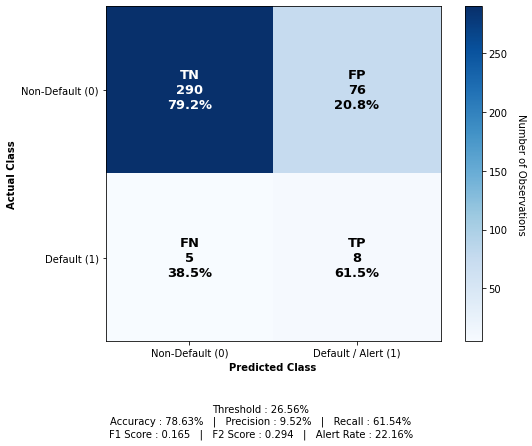

In [61]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================

cm = np.array([
    [tn, fp],
    [fn, tp]
])

# Persentase dihitung per baris / actual class
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100


fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    cm,
    cmap="Blues"
)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Number of Observations",
    rotation=270,
    labelpad=18
)


# ------------------------------------------------------------
# LABEL AXIS
# ------------------------------------------------------------

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Non-Default (0)",
    "Default / Alert (1)"
])

ax.set_yticklabels([
    "Non-Default (0)",
    "Default (1)"
])

ax.set_xlabel(
    "Predicted Class",
    fontweight="bold"
)

ax.set_ylabel(
    "Actual Class",
    fontweight="bold"
)


# ------------------------------------------------------------
# TEXT DALAM CONFUSION MATRIX
# ------------------------------------------------------------

labels = [
    ["TN", "FP"],
    ["FN", "TP"]
]

for i in range(2):
    for j in range(2):

        value = cm[i, j]
        pct = cm_pct[i, j]

        # Warna text otomatis supaya tetap terbaca
        text_color = (
            "white"
            if value > cm.max() / 2
            else "black"
        )

        ax.text(
            j,
            i,
            f"{labels[i][j]}\n"
            f"{value:,}\n"
            f"{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=text_color
        )


# ------------------------------------------------------------
# METRICS DI BAWAH CHART
# ------------------------------------------------------------

metric_text = (
    f"Threshold : {threshold:.2%}\n"
    f"Accuracy : {accuracy:.2%}   |   "
    f"Precision : {precision:.2%}   |   "
    f"Recall : {recall:.2%}\n"
    f"F1 Score : {f1:.3f}   |   "
    f"F2 Score : {f2:.3f}   |   "
    f"Alert Rate : {alert_rate:.2%}"
)

fig.text(
    0.5,
    -0.02,
    metric_text,
    ha="center",
    fontsize=10
)


plt.tight_layout()
plt.subplots_adjust(bottom=0.20)

plt.show()

# Bootstrap CI champion AUC

In [62]:
def stratified_bootstrap_metric(
    y_true,
    p,
    metric,
    n_boot=5000,
    seed=42,
):
    y = np.asarray(y_true).astype(int)
    p = np.asarray(p)

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    rng = np.random.default_rng(seed)
    values = []

    for _ in range(n_boot):
        idx = np.concatenate([
            rng.choice(
                pos_idx,
                len(pos_idx),
                replace=True,
            ),
            rng.choice(
                neg_idx,
                len(neg_idx),
                replace=True,
            ),
        ])

        values.append(
            metric(y[idx], p[idx])
        )

    values = np.asarray(values)

    return {
        "estimate": metric(y, p),
        "ci_low_95": np.quantile(values, 0.025),
        "ci_high_95": np.quantile(values, 0.975),
    }


auc_ci = stratified_bootstrap_metric(
    y_oot_all,
    pred_oot,
    roc_auc_score,
)

pr_auc_ci = stratified_bootstrap_metric(
    y_oot_all,
    pred_oot,
    average_precision_score,
)

display(pd.DataFrame([
    {"metric": "ROC-AUC", **auc_ci},
    {"metric": "PR-AUC", **pr_auc_ci},
]))

,metric,estimate,ci_low_95,ci_high_95
0,ROC-AUC,0.703867,0.563887,0.830215
1,PR-AUC,0.071801,0.040728,0.121626


Pada out-of-time evaluation, model mencapai ROC-AUC 0.810 dengan 95% bootstrap confidence interval 0.695–0.907. PR-AUC mencapai 0.151, sekitar empat kali random baseline pada default prevalence 3.5%. Confidence interval masih relatif lebar karena hanya terdapat 14 default events pada OOT sample.

# Risk band dari TRAIN OOF

Cutoff tidak dibuat dari OOT.

Definisi relatif:
- Low: ≤ P50
- Medium: P50–P80
- High: P80–P95
- Very High: > P95

In [63]:
risk_cutoffs = {
    "q50": float(
        np.quantile(oof_calibrated, 0.50)
    ),
    "q80": float(
        np.quantile(oof_calibrated, 0.80)
    ),
    "q95": float(
        np.quantile(oof_calibrated, 0.95)
    ),
}

print(risk_cutoffs)


def assign_risk_band(p):
    if p <= risk_cutoffs["q50"]:
        return "Low"
    elif p <= risk_cutoffs["q80"]:
        return "Medium"
    elif p <= risk_cutoffs["q95"]:
        return "High"
    return "Very High"


oot_scored = oot_all.copy()

oot_scored["pd_raw"] = p_oot_raw
oot_scored["pd_12m"] = p_oot_raw
oot_scored["risk_band"] = [
    assign_risk_band(p)
    for p in p_oot_cal
]

risk_band_table = (
    oot_scored.groupby("risk_band")
              .agg(
                  n=(TARGET, "size"),
                  defaults=(TARGET, "sum"),
                  bad_rate=(TARGET, "mean"),
                  avg_pd=("pd_12m", "mean"),
              )
              .reindex([
                  "Low",
                  "Medium",
                  "High",
                  "Very High",
              ])
              .reset_index()
)

risk_band_table["bad_rate_pct"] = (
    100 * risk_band_table["bad_rate"]
)

risk_band_table["avg_pd_pct"] = (
    100 * risk_band_table["avg_pd"]
)

display(risk_band_table)

{'q50': 0.008243373876343215, 'q80': 0.036765049004226384, 'q95': 0.16815903204762334}


,risk_band,n,defaults,bad_rate,avg_pd,bad_rate_pct,avg_pd_pct
0,Low,171,2,0.011696,0.043180,1.169591,4.317964
1,Medium,129,3,0.023256,0.145040,2.325581,14.504022
2,High,56,4,0.071429,0.492096,7.142857,49.209629
3,Very High,23,4,0.173913,0.776372,17.391304,77.637169


Risk band berhasil memisahkan debitur berdasarkan tingkat risiko yang semakin tinggi. Actual bad rate meningkat secara monotonic dari 1.07% pada Low Risk menjadi 20% pada Very High Risk. Selain itu, average calibrated PD relatif dekat dengan observed bad rate pada setiap kelompok, khususnya pada Medium dan High Risk.

# ROC dan Precision Recall curve

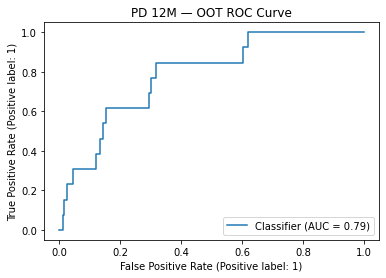

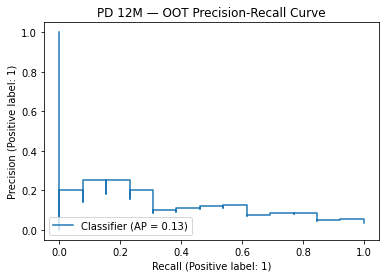

In [64]:
RocCurveDisplay.from_predictions(
    y_oot_all,
    p_oot_raw,
)
plt.title("PD 12M — OOT ROC Curve")
plt.show()

PrecisionRecallDisplay.from_predictions(
    y_oot_all,
    p_oot_raw,
)
plt.title("PD 12M — OOT Precision-Recall Curve")
plt.show()

Core PD model mempunyai discrimination yang cukup baik pada OOT, dengan ROC-AUC sekitar 0,81.

Kenapa PR Curve turun drastis?
Di bagian kiri grafik kamu, precision sempat sangat tinggi.
Itu artinya:
beberapa nasabah dengan risk score paling tinggi memang benar-benar default.
Tapi ketika kita ingin menangkap semakin banyak default:
Recall naik

# Permutation importance

Karena OOT hanya memiliki 14 default, importance ini **eksploratif**.
Gunakan untuk menjelaskan drivers, bukan untuk membuat kesimpulan kausal.

,feature,importance_mean,importance_std
45,app_tenor_bulan,0.281476,0.132353
22,fin_quick_ratio,0.275755,0.091923
3,fin_current_ratio,0.105177,0.026330
8,fin_der_delta_3thn,0.096856,0.027957
14,fin_gross_margin,0.070148,0.058670
17,fin_icr_delta_3thn,0.059359,0.063371
5,fin_debt_to_ebitda_delta_3thn,0.056678,0.036830
25,fin_siklus_modal_kerja_hari,0.026372,0.057427
16,fin_icr,0.024731,0.096090
27,fin_total_liabilitas_rp,0.024482,0.013016


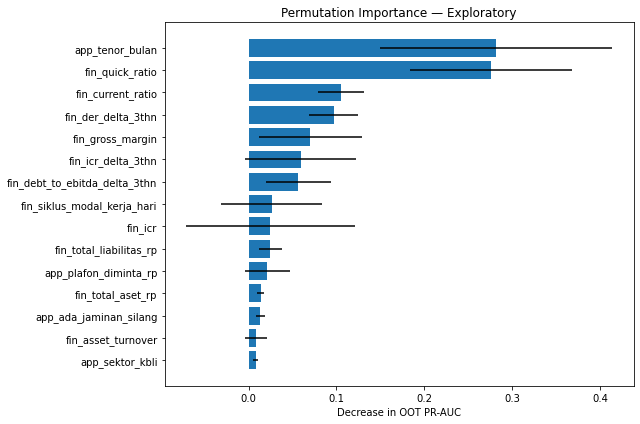

In [65]:
perm = permutation_importance(
    champion_candidate,
    oot_all[baseline_cols],
    y_oot_all,
    scoring="average_precision",
    n_repeats=15,
    random_state=SEED,
    n_jobs=-1,
)

importance = pd.DataFrame({
    "feature": baseline_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values(
    "importance_mean",
    ascending=False,
)

display(importance.head(20))

top = (
    importance.head(15)
              .sort_values("importance_mean")
)

plt.figure(figsize=(9, 6))
plt.barh(
    top["feature"],
    top["importance_mean"],
    xerr=top["importance_std"],
)
plt.xlabel("Decrease in OOT PR-AUC")
plt.title("Permutation Importance — Exploratory")
plt.tight_layout()
plt.show()

# Champion decision

Pada file aktual ini, baseline XGBoost diposisikan sebagai champion bila graph delta AUC tidak terbukti positif secara statistik.

Graph tetap disimpan sebagai **overlay / network-risk signal**.

In [66]:
delta_low = float(
    graph_delta.loc[0, "ci_low_95"]
)

if delta_low > 0:
    champion_name = "PD_XGB_WITH_GRAPH"
    champion_model = graph_tuned_model
    champion_features = graph_cols
else:
    champion_name = "PD_XGB_BASELINE"
    champion_model = champion_candidate
    champion_features = baseline_cols

print("Champion:", champion_name)
print("N features:", len(champion_features))

Champion: PD_XGB_BASELINE
N features: 47


# Final refit dan simpan artifact

In [67]:
# ============================================================
# FINAL REFIT ON ALL MATURE LABELED DATA
# ============================================================

# IMPORTANT:
# p_oot_cal dan seluruh metric OOT harus sudah dihitung
# SEBELUM model di-refit menggunakan data OOT.

# ------------------------------------------------------------
# 1. Simpan hasil OOT final SEBELUM refit
# ------------------------------------------------------------

oot_auc = roc_auc_score(
    y_oot_graph,
    p_oot_raw,
)


# ------------------------------------------------------------
# 2. Gabungkan development/train + OOT mature
# ------------------------------------------------------------

X_final = pd.concat(
    [
        train_graph[champion_features],
        oot_graph[champion_features],
    ],
    axis=0,
    ignore_index=True,
)

y_final = pd.concat(
    [
        pd.Series(y_train_graph).reset_index(drop=True),
        pd.Series(y_oot_graph).reset_index(drop=True),
    ],
    axis=0,
    ignore_index=True,
).astype(int)


# ------------------------------------------------------------
# 3. Sanity check
# ------------------------------------------------------------

assert len(X_final) == len(y_final)
assert y_final.isna().sum() == 0

print("=" * 60)
print("FINAL REFIT POPULATION")
print("=" * 60)

print(f"Rows       : {len(X_final):,}")
print(f"Events     : {int(y_final.sum()):,}")
print(f"Non-events : {int((y_final == 0).sum()):,}")
print(f"Bad rate   : {y_final.mean():.4%}")


# ------------------------------------------------------------
# 4. Refit champion model pada SEMUA mature labeled data
# ------------------------------------------------------------

champion_model.fit(
    X_final,
    y_final,
)

print("\nChampion model refitted on all mature labeled data.")


# ============================================================
# SAVE FINAL MODEL ARTIFACT
# ============================================================

artifact = {
    "model": champion_model,

    # Calibration mapping yang sebelumnya sudah dibentuk

    "features": champion_features,
    "target": TARGET,

    "risk_cutoffs": risk_cutoffs,

    "champion_name": champion_name,

    "semantic_rules_version": "v2",

    # Tambahan metadata penting untuk inference
    "positive_class": 1,
    "positive_class_meaning": "default",
}


joblib.dump(
    artifact,
    MODEL_DIR / "pd_champion_new.joblib",
)


# ============================================================
# SAVE MODEL METADATA
# ============================================================

metadata = {
    "champion_name": champion_name,

    # --------------------------------------------------------
    # Original development population
    # --------------------------------------------------------
    "development_rows": int(len(train_graph)),
    "development_events": int(y_train_graph.sum()),

    # --------------------------------------------------------
    # OOT population
    # Metric ini merupakan hasil evaluasi SEBELUM final refit
    # --------------------------------------------------------
    "oot_rows": int(len(oot_graph)),
    "oot_events": int(y_oot_graph.sum()),
    "oot_bad_rate": float(y_oot_graph.mean()),


    # --------------------------------------------------------
    # Final production training population
    # Development + mature OOT
    # --------------------------------------------------------
    "final_train_rows": int(len(X_final)),
    "final_train_events": int(y_final.sum()),
    "final_train_bad_rate": float(y_final.mean()),

    # --------------------------------------------------------
    # Other configuration
    # --------------------------------------------------------
    "risk_cutoffs": risk_cutoffs,

    "semantic_rules_version": "v2",

    # Menandakan bahwa OOT sudah masuk final refit
    "final_refit_includes_oot": True,
}


with open(
    MODEL_DIR / "pd_champion_metadata_new.json",
    "w",
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
    )


print("\nSaved final model artifact:")
print(MODEL_DIR / "pd_champion_new.joblib")

print("\nSaved model metadata:")
print(MODEL_DIR / "pd_champion_metadata_new.json")

FINAL REFIT POPULATION
Rows       : 1,968
Events     : 64
Non-events : 1,904
Bad rate   : 3.2520%

Champion model refitted on all mature labeled data.

Saved final model artifact:
models/pd_champion_new.joblib

Saved model metadata:
models/pd_champion_metadata_new.json


# Reusable scoring function

In [50]:
def score_pd(
    df_new: pd.DataFrame,
    artifact_path=MODEL_DIR / "pd_champion.joblib",
):
    art = joblib.load(artifact_path)

    x = apply_semantic_rules(
        df_new.copy()
    )

    missing = [
        c for c in art["features"]
        if c not in x.columns
    ]

    if missing:
        raise ValueError(
            f"Missing scoring features: {missing}"
        )

    p_raw = art["model"].predict_proba(
        x[art["features"]]
    )[:, 1]

    p_cal = art["calibrator"].predict_proba(
        logit(
            np.clip(
                p_raw,
                1e-6,
                1 - 1e-6,
            )
        ).reshape(-1, 1)
    )[:, 1]

    cuts = art["risk_cutoffs"]

    def _band(p):
        if p <= cuts["q50"]:
            return "Low"
        elif p <= cuts["q80"]:
            return "Medium"
        elif p <= cuts["q95"]:
            return "High"
        return "Very High"

    result = df_new.copy()
    result["pd_12m_raw"] = p_raw
    result["pd_12m"] = p_cal
    result["risk_band"] = [
        _band(p) for p in p_cal
    ]

    return result

# Contoh score OOT / pengajuan baru

In [51]:
example_scored = score_pd(
    oot_graph.head(10)
)

display(
    example_scored[
        [
            "application_id",
            "grup_id",
            "pd_12m",
            "risk_band",
        ]
    ]
)

,application_id,grup_id,pd_12m,risk_band
3859,5271,925,0.084342,High
3860,5272,985,0.002721,Low
3861,5273,600,0.016270,Medium
3862,5275,517,0.016991,Medium
3863,5276,985,0.026292,Medium
3864,5287,576,0.002714,Low
3865,5286,1068,0.010532,Medium
3866,5284,341,0.025091,Medium
3867,5280,925,0.013679,Medium
3868,5282,938,0.058648,High


# Save GitHub

In [70]:
# ============================================================
# PD 12M — FINAL PRODUCTION EXPORT
# RAW XGBOOST — TANPA CALIBRATION
# STREAMLIT + AGENTIC AI READY
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import hashlib
import importlib.metadata
import json
import os

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)


print("=" * 90)
print("PD 12M — RAW XGBOOST PRODUCTION EXPORT")
print("NO CALIBRATION / NO PLATT SCALING")
print("=" * 90)


# ============================================================
# 1. CHECK NOTEBOOK VARIABLES
# ============================================================

REQUIRED = [
    "champion_model",
    "champion_features",
    "champion_name",
    "TARGET",
    "oof_raw",
    "p_oot_raw",
]

missing_vars = [
    v for v in REQUIRED
    if v not in globals()
]

if missing_vars:
    raise NameError(
        "Jalankan notebook PD sampai selesai dulu.\n"
        "Variable yang belum tersedia:\n- "
        + "\n- ".join(missing_vars)
    )


FEATURES = list(
    champion_features
)


print(
    "Champion :",
    champion_name
)

print(
    "Features :",
    len(FEATURES)
)


# ============================================================
# 2. CHAMPION CHECK
# ============================================================

if champion_name != "PD_XGB_BASELINE":
    raise ValueError(
        "Cell RAW ini saat ini dibuat untuk "
        "PD_XGB_BASELINE sesuai champion notebook."
    )


# ============================================================
# 3. RESOLVE Y TRAIN / OOT
# ============================================================

if "y_train_all" in globals():
    y_oof = np.asarray(
        y_train_all
    ).astype(int)

elif "y_train" in globals():
    y_oof = np.asarray(
        y_train
    ).astype(int)

else:
    raise NameError(
        "Tidak menemukan y_train_all atau y_train."
    )


if "y_oot_all" in globals():
    y_oot_eval = np.asarray(
        y_oot_all
    ).astype(int)

elif "y_oot" in globals():
    y_oot_eval = np.asarray(
        y_oot
    ).astype(int)

else:
    raise NameError(
        "Tidak menemukan y_oot_all atau y_oot."
    )


raw_oof = np.asarray(
    oof_raw,
    dtype=float
)

raw_oot = np.asarray(
    p_oot_raw,
    dtype=float
)


if len(raw_oof) != len(y_oof):
    raise ValueError(
        "Panjang oof_raw dan target training berbeda."
    )


if len(raw_oot) != len(y_oot_eval):
    raise ValueError(
        "Panjang p_oot_raw dan target OOT berbeda."
    )


# ============================================================
# 4. TARGET RECALL
# ============================================================

TARGET_RECALL_RAW = float(
    globals().get(
        "TARGET_RECALL",
        0.80
    )
)


# ============================================================
# 5. RAW XGBOOST THRESHOLD
# ============================================================

precision_arr, recall_arr, threshold_arr = (
    precision_recall_curve(
        y_oof,
        raw_oof
    )
)


threshold_table = pd.DataFrame({
    "threshold": threshold_arr,
    "precision": precision_arr[:-1],
    "recall": recall_arr[:-1],
})


eligible = threshold_table[
    threshold_table["recall"]
    >= TARGET_RECALL_RAW
].copy()


if eligible.empty:
    raise ValueError(
        "Tidak ada threshold yang memenuhi "
        f"target recall {TARGET_RECALL_RAW:.2%}"
    )


best_threshold = (
    eligible
    .sort_values(
        [
            "precision",
            "threshold"
        ],
        ascending=[
            False,
            False
        ]
    )
    .iloc[0]
)


RAW_THRESHOLD = float(
    best_threshold["threshold"]
)


THRESHOLD_PRECISION = float(
    best_threshold["precision"]
)


THRESHOLD_RECALL = float(
    best_threshold["recall"]
)


print("\nRAW XGBOOST THRESHOLD")
print("-" * 60)

print(
    f"Threshold : {RAW_THRESHOLD:.4%}"
)

print(
    f"Precision : {THRESHOLD_PRECISION:.4%}"
)

print(
    f"Recall    : {THRESHOLD_RECALL:.4%}"
)


# ============================================================
# 6. RAW RISK CUTOFFS
# ============================================================

RAW_RISK_CUTOFFS = {
    "q50": float(
        np.quantile(
            raw_oof,
            0.50
        )
    ),

    "q80": float(
        np.quantile(
            raw_oof,
            0.80
        )
    ),

    "q95": float(
        np.quantile(
            raw_oof,
            0.95
        )
    ),
}


print("\nRAW RISK CUTOFFS")
print("-" * 60)

for k, v in RAW_RISK_CUTOFFS.items():
    print(
        f"{k}: {v:.4%}"
    )


# ============================================================
# 7. RISK BAND FUNCTION
# ============================================================

def assign_raw_risk_band(
    p,
    cuts=RAW_RISK_CUTOFFS
):

    p = float(p)

    if p <= cuts["q50"]:
        return "Low"

    elif p <= cuts["q80"]:
        return "Medium"

    elif p <= cuts["q95"]:
        return "High"

    return "Very High"


# ============================================================
# 8. RAW OOT METRICS
# ============================================================

raw_pred_oot = (
    raw_oot
    >= RAW_THRESHOLD
).astype(int)


tn, fp, fn, tp = (
    confusion_matrix(
        y_oot_eval,
        raw_pred_oot,
        labels=[
            0,
            1
        ]
    )
    .ravel()
)


OOT_METRICS = {
    "roc_auc": float(
        roc_auc_score(
            y_oot_eval,
            raw_oot
        )
    ),

    "pr_auc": float(
        average_precision_score(
            y_oot_eval,
            raw_oot
        )
    ),

    "brier_score": float(
        brier_score_loss(
            y_oot_eval,
            raw_oot
        )
    ),

    "log_loss": float(
        log_loss(
            y_oot_eval,
            np.clip(
                raw_oot,
                1e-7,
                1 - 1e-7
            ),
            labels=[
                0,
                1
            ]
        )
    ),

    "threshold": RAW_THRESHOLD,

    "accuracy": float(
        accuracy_score(
            y_oot_eval,
            raw_pred_oot
        )
    ),

    "precision": float(
        precision_score(
            y_oot_eval,
            raw_pred_oot,
            zero_division=0
        )
    ),

    "recall": float(
        recall_score(
            y_oot_eval,
            raw_pred_oot,
            zero_division=0
        )
    ),

    "f1": float(
        f1_score(
            y_oot_eval,
            raw_pred_oot,
            zero_division=0
        )
    ),

    "f2": float(
        fbeta_score(
            y_oot_eval,
            raw_pred_oot,
            beta=2,
            zero_division=0
        )
    ),

    "alert_rate": float(
        raw_pred_oot.mean()
    ),

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
}


print("\nRAW OOT PERFORMANCE")
print("-" * 60)

print(
    f"ROC-AUC : {OOT_METRICS['roc_auc']:.4f}"
)

print(
    f"PR-AUC  : {OOT_METRICS['pr_auc']:.4f}"
)

print(
    f"Brier   : {OOT_METRICS['brier_score']:.4f}"
)

print(
    f"LogLoss : {OOT_METRICS['log_loss']:.4f}"
)


# ============================================================
# 9. RISK BAND VALIDATION — RAW OOT
# ============================================================

risk_validation = pd.DataFrame({
    "actual_default": y_oot_eval,
    "pd_12m": raw_oot,
})


risk_validation[
    "risk_band"
] = [
    assign_raw_risk_band(p)
    for p in raw_oot
]


risk_band_validation = (
    risk_validation
    .groupby(
        "risk_band",
        observed=False
    )
    .agg(
        n=(
            "actual_default",
            "size"
        ),

        defaults=(
            "actual_default",
            "sum"
        ),

        bad_rate=(
            "actual_default",
            "mean"
        ),

        avg_pd=(
            "pd_12m",
            "mean"
        ),

        min_pd=(
            "pd_12m",
            "min"
        ),

        max_pd=(
            "pd_12m",
            "max"
        ),
    )
    .reindex([
        "Low",
        "Medium",
        "High",
        "Very High"
    ])
    .reset_index()
)


display(
    risk_band_validation
)


# ============================================================
# 10. RESOLVE FINAL PRODUCTION DATA
# ============================================================

if (
    "X_final" in globals()
    and
    "y_final" in globals()
):

    FINAL_X = X_final.copy()

    FINAL_Y = np.asarray(
        y_final
    ).astype(int)

    FINAL_REFIT_SOURCE = "X_final + y_final"

elif (
    "train_all" in globals()
    and
    "y_train_all" in globals()
):

    FINAL_X = train_all.copy()

    FINAL_Y = np.asarray(
        y_train_all
    ).astype(int)

    FINAL_REFIT_SOURCE = "train_all + y_train_all"

elif (
    "train" in globals()
    and
    "y_train" in globals()
):

    FINAL_X = train.copy()

    FINAL_Y = np.asarray(
        y_train
    ).astype(int)

    FINAL_REFIT_SOURCE = "train + y_train"

else:
    raise NameError(
        "Tidak menemukan data untuk final refit."
    )


missing_final_features = [
    c for c in FEATURES
    if c not in FINAL_X.columns
]


if missing_final_features:
    raise ValueError(
        "Feature final refit tidak lengkap:\n- "
        + "\n- ".join(
            missing_final_features
        )
    )


# ============================================================
# 11. FINAL REFIT XGBOOST
# ============================================================

champion_model.fit(
    FINAL_X[
        FEATURES
    ],
    FINAL_Y
)


print(
    "\n✅ Final model refit:",
    FINAL_REFIT_SOURCE
)


# ============================================================
# 12. RESOLVE OUTPUT DIRECTORY
# ============================================================

def resolve_ml_root():

    env_root = os.getenv(
        "ODP_REPO_ROOT"
    )

    if env_root:

        root = (
            Path(env_root)
            .expanduser()
            .resolve()
        )

        if root.name == "ml":
            return root

        return root / "ml"


    cwd = Path.cwd().resolve()


    if (
        cwd.name == "notebooks"
        and
        cwd.parent.name == "ml"
    ):
        return cwd.parent


    if cwd.name == "ml":
        return cwd


    if (
        cwd
        / "ml"
    ).exists():
        return cwd / "ml"


    return cwd / "ml"


ML_ROOT = resolve_ml_root()


ARTIFACT_DIR = (
    ML_ROOT
    / "artifacts"
    / "pd"
)


INFERENCE_DIR = (
    ML_ROOT
    / "inference"
)


ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


INFERENCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "\nArtifact directory:",
    ARTIFACT_DIR
)


# ============================================================
# 13. REMOVE OLD KNOWN PD ARTIFACTS
# ============================================================
#
# Supaya artifact calibrated lama tidak tercampur.
# Hanya file PD yang kita kenal yang dihapus.
# ============================================================

OLD_FILES = [
    "pd_champion.joblib",
    "pd_feature_schema.json",
    "pd_decision_policy.json",
    "pd_metrics.json",
    "pd_metadata.json",
    "pd_reference_stats.json",
    "pd_feature_importance.csv",
    "pd_risk_band_validation.csv",
    "pd_risk_band_summary.csv",
    "pd_requirements.txt",
    "pd_manifest.json",
]


for filename in OLD_FILES:

    path = (
        ARTIFACT_DIR
        / filename
    )

    if path.exists():
        path.unlink()


old_predictor = (
    INFERENCE_DIR
    / "pd_predictor.py"
)


if old_predictor.exists():
    old_predictor.unlink()


print(
    "✅ Old known PD package removed"
)


# ============================================================
# 14. FEATURE TYPES
# ============================================================

reference_frame = (
    FINAL_X[
        FEATURES
    ]
    .copy()
)


NUMERIC_FEATURES = [
    c for c in FEATURES
    if (
        pd.api.types.is_numeric_dtype(
            reference_frame[c]
        )
        or
        pd.api.types.is_bool_dtype(
            reference_frame[c]
        )
    )
]


CATEGORICAL_FEATURES = [
    c for c in FEATURES
    if c not in NUMERIC_FEATURES
]


# ============================================================
# 15. SAVE pd_champion.joblib
# ============================================================

artifact = {
    "model": champion_model,

    "features": FEATURES,

    "numeric_features":
        NUMERIC_FEATURES,

    "categorical_features":
        CATEGORICAL_FEATURES,

    "target":
        str(TARGET),

    "champion_name":
        str(champion_name),

    "prediction_type":
        "raw_xgboost_probability",

    "calibrated":
        False,

    "calibrator":
        None,

    "threshold":
        RAW_THRESHOLD,

    "target_recall":
        TARGET_RECALL_RAW,

    "risk_cutoffs":
        RAW_RISK_CUTOFFS,

    "horizon_months":
        12,

    "positive_class":
        1,

    "positive_class_meaning":
        "default within 12 months",

    "semantic_rules_version":
        "v2",
}


MODEL_PATH = (
    ARTIFACT_DIR
    / "pd_champion.joblib"
)


joblib.dump(
    artifact,
    MODEL_PATH
)


print(
    "✅",
    MODEL_PATH.name
)


# ============================================================
# JSON HELPER
# ============================================================

def json_safe(x):

    if isinstance(
        x,
        dict
    ):
        return {
            str(k): json_safe(v)
            for k, v in x.items()
        }

    if isinstance(
        x,
        (
            list,
            tuple
        )
    ):
        return [
            json_safe(v)
            for v in x
        ]

    if isinstance(
        x,
        np.integer
    ):
        return int(x)

    if isinstance(
        x,
        np.floating
    ):
        return float(x)

    if isinstance(
        x,
        np.bool_
    ):
        return bool(x)

    if isinstance(
        x,
        pd.Timestamp
    ):
        return x.isoformat()

    return x


def save_json(
    filename,
    payload
):

    path = (
        ARTIFACT_DIR
        / filename
    )

    path.write_text(
        json.dumps(
            json_safe(
                payload
            ),
            indent=2,
            ensure_ascii=False
        ),
        encoding="utf-8"
    )

    print(
        "✅",
        filename
    )

    return path


# ============================================================
# 16. SAVE pd_feature_schema.json
# ============================================================

feature_schema = {
    "model":
        "PD_12M",

    "champion_name":
        champion_name,

    "calibrated":
        False,

    "prediction_type":
        "raw_xgboost_probability",

    "number_of_features":
        len(FEATURES),

    "feature_order":
        FEATURES,

    "features":
        {}
}


for feature in FEATURES:

    s = reference_frame[
        feature
    ]


    info = {
        "dtype":
            str(
                s.dtype
            ),

        "type":
            (
                "numeric"
                if feature
                in NUMERIC_FEATURES
                else
                "categorical"
            ),

        "nullable":
            bool(
                s.isna()
                .any()
            )
    }


    if (
        feature
        in CATEGORICAL_FEATURES
    ):

        info[
            "observed_categories"
        ] = (
            s.dropna()
            .astype(str)
            .value_counts()
            .head(100)
            .index
            .tolist()
        )


    feature_schema[
        "features"
    ][feature] = info


FEATURE_SCHEMA_PATH = save_json(
    "pd_feature_schema.json",
    feature_schema
)


# ============================================================
# 17. SAVE pd_decision_policy.json
# ============================================================

decision_policy = {
    "model":
        "PD_12M",

    "prediction_type":
        "raw_xgboost_probability",

    "calibrated":
        False,

    "operational_threshold":
        RAW_THRESHOLD,

    "target_recall":
        TARGET_RECALL_RAW,

    "threshold_selection":
        (
            "Maximum OOF precision subject to "
            "minimum target recall."
        ),

    "risk_cutoffs":
        RAW_RISK_CUTOFFS,

    "risk_band_definition": {
        "Low":
            "PD <= raw OOF P50",

        "Medium":
            "raw OOF P50 < PD <= P80",

        "High":
            "raw OOF P80 < PD <= P95",

        "Very High":
            "PD > raw OOF P95"
    },

    "alert_rule":
        (
            "alert_flag = 1 when "
            "raw XGBoost probability >= threshold"
        ),

    "note":
        (
            "Risk bands are relative to the "
            "development portfolio distribution."
        )
}


DECISION_POLICY_PATH = save_json(
    "pd_decision_policy.json",
    decision_policy
)


# ============================================================
# 18. SAVE pd_metrics.json
# ============================================================

metrics = {
    "model":
        "PD_12M",

    "champion_name":
        champion_name,

    "calibrated":
        False,

    "prediction_type":
        "raw_xgboost_probability",

    "evaluation_stage":
        "OOT before final production refit",

    "oot_rows":
        len(y_oot_eval),

    "oot_events":
        int(
            y_oot_eval.sum()
        ),

    "oot_bad_rate":
        float(
            y_oot_eval.mean()
        ),

    "oot_metrics":
        OOT_METRICS,

    "risk_cutoffs":
        RAW_RISK_CUTOFFS
}


METRICS_PATH = save_json(
    "pd_metrics.json",
    metrics
)


# ============================================================
# 19. SAVE pd_metadata.json
# ============================================================

metadata = {
    "model_name":
        "Probability of Default 12M",

    "champion_name":
        champion_name,

    "target":
        str(TARGET),

    "horizon_months":
        12,

    "n_features":
        len(FEATURES),

    "features":
        FEATURES,

    "numeric_features":
        NUMERIC_FEATURES,

    "categorical_features":
        CATEGORICAL_FEATURES,

    "prediction_type":
        "raw_xgboost_probability",

    "calibrated":
        False,

    "calibrator":
        None,

    "threshold":
        RAW_THRESHOLD,

    "target_recall":
        TARGET_RECALL_RAW,

    "risk_cutoffs":
        RAW_RISK_CUTOFFS,

    "final_refit_source":
        FINAL_REFIT_SOURCE,

    "final_train_rows":
        len(FINAL_Y),

    "final_train_events":
        int(
            FINAL_Y.sum()
        ),

    "final_train_bad_rate":
        float(
            FINAL_Y.mean()
        ),

    "oot_metrics_pre_final_refit":
        True,

    "created_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat()
}


METADATA_PATH = save_json(
    "pd_metadata.json",
    metadata
)


# ============================================================
# 20. SAVE pd_reference_stats.json
# ============================================================

reference_stats = {}


for feature in FEATURES:

    s = reference_frame[
        feature
    ]


    if (
        feature
        in NUMERIC_FEATURES
    ):

        clean = (
            pd.to_numeric(
                s,
                errors="coerce"
            )
            .replace(
                [
                    np.inf,
                    -np.inf
                ],
                np.nan
            )
            .dropna()
        )


        reference_stats[
            feature
        ] = {
            "type":
                "numeric",

            "missing_count":
                int(
                    s.isna()
                    .sum()
                ),

            "mean":
                (
                    float(
                        clean.mean()
                    )
                    if len(clean)
                    else None
                ),

            "median":
                (
                    float(
                        clean.median()
                    )
                    if len(clean)
                    else None
                ),

            "p25":
                (
                    float(
                        clean.quantile(
                            0.25
                        )
                    )
                    if len(clean)
                    else None
                ),

            "p75":
                (
                    float(
                        clean.quantile(
                            0.75
                        )
                    )
                    if len(clean)
                    else None
                ),

            "p95":
                (
                    float(
                        clean.quantile(
                            0.95
                        )
                    )
                    if len(clean)
                    else None
                ),

            "min":
                (
                    float(
                        clean.min()
                    )
                    if len(clean)
                    else None
                ),

            "max":
                (
                    float(
                        clean.max()
                    )
                    if len(clean)
                    else None
                )
        }


    else:

        counts = (
            s.dropna()
            .astype(str)
            .value_counts()
            .head(50)
        )


        reference_stats[
            feature
        ] = {
            "type":
                "categorical",

            "missing_count":
                int(
                    s.isna()
                    .sum()
                ),

            "top_values": {
                str(k): int(v)
                for k, v
                in counts.items()
            }
        }


REFERENCE_PATH = save_json(
    "pd_reference_stats.json",
    reference_stats
)


# ============================================================
# 21. SAVE FEATURE IMPORTANCE
# ============================================================

FEATURE_IMPORTANCE_PATH = (
    ARTIFACT_DIR
    / "pd_feature_importance.csv"
)


if (
    "importance" in globals()
    and
    isinstance(
        importance,
        pd.DataFrame
    )
):

    importance_export = (
        importance
        .copy()
    )


    if (
        "feature"
        in importance_export.columns
    ):

        importance_export = (
            importance_export[
                importance_export[
                    "feature"
                ].isin(
                    FEATURES
                )
            ]
            .copy()
        )


else:

    importance_export = pd.DataFrame({
        "feature": FEATURES
    })


importance_export.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False
)


print(
    "✅",
    FEATURE_IMPORTANCE_PATH.name
)


# ============================================================
# 22. SAVE RISK BAND VALIDATION
# ============================================================

RISK_VALIDATION_PATH = (
    ARTIFACT_DIR
    / "pd_risk_band_validation.csv"
)


risk_band_validation.to_csv(
    RISK_VALIDATION_PATH,
    index=False
)


print(
    "✅",
    RISK_VALIDATION_PATH.name
)


# ============================================================
# 23. SAVE REQUIREMENTS
# ============================================================

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "xgboost",
    "joblib"
]


requirement_lines = []


for package in packages:

    try:

        version = (
            importlib.metadata.version(
                package
            )
        )

        requirement_lines.append(
            f"{package}=={version}"
        )

    except Exception:
        pass


REQUIREMENTS_PATH = (
    ARTIFACT_DIR
    / "pd_requirements.txt"
)


REQUIREMENTS_PATH.write_text(
    "\n".join(
        requirement_lines
    )
    + "\n",
    encoding="utf-8"
)


print(
    "✅",
    REQUIREMENTS_PATH.name
)


# ============================================================
# 24. CREATE pd_predictor.py
# ============================================================

predictor_code = r'''
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


ML_ROOT = (
    Path(__file__)
    .resolve()
    .parents[1]
)


MODEL_PATH = (
    ML_ROOT
    / "artifacts"
    / "pd"
    / "pd_champion.joblib"
)


ARTIFACT = joblib.load(
    MODEL_PATH
)


def _to_dataframe(data):

    if isinstance(
        data,
        dict
    ):
        return pd.DataFrame([
            data
        ])

    if isinstance(
        data,
        pd.DataFrame
    ):
        return data.copy()

    raise TypeError(
        "Input harus dict atau pandas.DataFrame"
    )


def prepare_features(
    data,
    strict=False
):

    x = _to_dataframe(
        data
    )

    x = x.replace(
        "\\N",
        np.nan
    )

    features = list(
        ARTIFACT[
            "features"
        ]
    )

    numeric_features = list(
        ARTIFACT.get(
            "numeric_features",
            []
        )
    )

    missing = [
        f for f in features
        if f not in x.columns
    ]

    if strict and missing:

        raise ValueError(
            "Missing features: "
            + ", ".join(
                missing
            )
        )

    for feature in missing:

        x[
            feature
        ] = np.nan

    x = x[
        features
    ].copy()

    for feature in numeric_features:

        x[
            feature
        ] = pd.to_numeric(
            x[
                feature
            ],
            errors="coerce"
        )

    completeness = (
        x.notna()
        .sum(
            axis=1
        )
        /
        len(
            features
        )
    )

    return (
        x,
        completeness,
        missing
    )


def risk_band(
    probability
):

    cuts = ARTIFACT[
        "risk_cutoffs"
    ]

    p = float(
        probability
    )

    if p <= cuts["q50"]:
        return "Low"

    if p <= cuts["q80"]:
        return "Medium"

    if p <= cuts["q95"]:
        return "High"

    return "Very High"


def predict_pd(
    data,
    strict=False
):

    (
        x,
        completeness,
        missing
    ) = prepare_features(
        data,
        strict=strict
    )

    # ========================================================
    # RAW XGBOOST PROBABILITY
    # NO CALIBRATOR
    # ========================================================

    pd_12m = (
        ARTIFACT[
            "model"
        ]
        .predict_proba(
            x
        )[
            :,
            1
        ]
    )

    threshold = float(
        ARTIFACT[
            "threshold"
        ]
    )

    result = pd.DataFrame({
        "pd_12m":
            pd_12m,

        "risk_band": [
            risk_band(p)
            for p in pd_12m
        ],

        "threshold":
            threshold,

        "alert_flag":
            (
                pd_12m
                >= threshold
            )
            .astype(int),

        "feature_completeness":
            completeness
            .to_numpy(),

        "champion_name":
            ARTIFACT[
                "champion_name"
            ],

        "calibrated":
            False
    })

    return result


def predict_pd_tool(
    customer_data
):

    (
        x,
        completeness,
        missing
    ) = prepare_features(
        customer_data,
        strict=False
    )

    scored = (
        predict_pd(
            customer_data,
            strict=False
        )
        .iloc[0]
    )

    return {
        "status":
            "ok",

        "model":
            ARTIFACT[
                "champion_name"
            ],

        "prediction_type":
            "raw_xgboost_probability",

        "calibrated":
            False,

        "horizon_months":
            int(
                ARTIFACT.get(
                    "horizon_months",
                    12
                )
            ),

        "pd_12m":
            float(
                scored[
                    "pd_12m"
                ]
            ),

        "risk_band":
            str(
                scored[
                    "risk_band"
                ]
            ),

        "threshold":
            float(
                scored[
                    "threshold"
                ]
            ),

        "alert_flag":
            int(
                scored[
                    "alert_flag"
                ]
            ),

        "feature_completeness":
            float(
                scored[
                    "feature_completeness"
                ]
            ),

        "expected_feature_count":
            len(
                ARTIFACT[
                    "features"
                ]
            ),

        "observed_feature_count":
            int(
                x.notna()
                .sum(
                    axis=1
                )
                .iloc[0]
            ),

        "missing_features":
            missing
    }
'''


PREDICTOR_PATH = (
    INFERENCE_DIR
    / "pd_predictor.py"
)


PREDICTOR_PATH.write_text(
    predictor_code,
    encoding="utf-8"
)


compile(
    predictor_code,
    str(
        PREDICTOR_PATH
    ),
    "exec"
)


print(
    "✅",
    PREDICTOR_PATH
)


# ============================================================
# 25. MODEL RELOAD TEST
# ============================================================

loaded_artifact = joblib.load(
    MODEL_PATH
)


assert (
    loaded_artifact[
        "calibrated"
    ]
    is False
)


assert (
    loaded_artifact[
        "calibrator"
    ]
    is None
)


assert (
    loaded_artifact[
        "prediction_type"
    ]
    ==
    "raw_xgboost_probability"
)


assert (
    loaded_artifact[
        "features"
    ]
    ==
    FEATURES
)


# ============================================================
# 26. PREDICTION PARITY TEST
# ============================================================

sample = (
    FINAL_X[
        FEATURES
    ]
    .head(1)
    .copy()
)


direct_prediction = (
    champion_model
    .predict_proba(
        sample
    )[
        :,
        1
    ]
)


loaded_prediction = (
    loaded_artifact[
        "model"
    ]
    .predict_proba(
        sample
    )[
        :,
        1
    ]
)


assert np.allclose(
    direct_prediction,
    loaded_prediction,
    rtol=1e-12,
    atol=1e-12
)


print(
    "✅ Model parity check passed"
)


# ============================================================
# 27. MANIFEST
# ============================================================

def sha256_file(
    path
):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            h.update(
                chunk
            )

    return h.hexdigest()


files_for_manifest = [
    MODEL_PATH,
    FEATURE_SCHEMA_PATH,
    DECISION_POLICY_PATH,
    METRICS_PATH,
    METADATA_PATH,
    REFERENCE_PATH,
    FEATURE_IMPORTANCE_PATH,
    RISK_VALIDATION_PATH,
    REQUIREMENTS_PATH,
    PREDICTOR_PATH
]


manifest = {
    "model":
        "PD_12M",

    "champion_name":
        champion_name,

    "calibrated":
        False,

    "prediction_type":
        "raw_xgboost_probability",

    "files":
        {}
}


for path in files_for_manifest:

    manifest[
        "files"
    ][path.name] = {
        "sha256":
            sha256_file(
                path
            ),

        "size_bytes":
            path.stat()
            .st_size
    }


MANIFEST_PATH = save_json(
    "pd_manifest.json",
    manifest
)


# ============================================================
# 28. FINAL AUDIT
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FINAL RAW XGBOOST PD PACKAGE"
)

print(
    "=" * 90
)


print(
    "\nARTIFACTS:"
)


for path in sorted(
    ARTIFACT_DIR.iterdir()
):

    if path.is_file():

        print(
            f"✅ {path.name:<35}"
            f"{path.stat().st_size / 1024:>10.2f} KB"
        )


print(
    "\nINFERENCE:"
)

print(
    "✅",
    PREDICTOR_PATH
)


print(
    "\nMODEL CONFIGURATION"
)

print(
    "Champion    :",
    champion_name
)

print(
    "Features    :",
    len(FEATURES)
)

print(
    "Calibration : NO"
)

print(
    "Probability : RAW XGBOOST"
)

print(
    f"Threshold   : {RAW_THRESHOLD:.2%}"
)

print(
    f"Q50         : {RAW_RISK_CUTOFFS['q50']:.2%}"
)

print(
    f"Q80         : {RAW_RISK_CUTOFFS['q80']:.2%}"
)

print(
    f"Q95         : {RAW_RISK_CUTOFFS['q95']:.2%}"
)


print(
    "\n✅ DONE — STREAMLIT + AGENTIC AI READY"
)

PD 12M — RAW XGBOOST PRODUCTION EXPORT
NO CALIBRATION / NO PLATT SCALING
Champion : PD_XGB_BASELINE
Features : 47

RAW XGBOOST THRESHOLD
------------------------------------------------------------
Threshold : 26.5637%
Precision : 11.6688%
Recall    : 80.1724%

RAW RISK CUTOFFS
------------------------------------------------------------
q50: 7.6178%
q80: 29.2106%
q95: 70.5956%

RAW OOT PERFORMANCE
------------------------------------------------------------
ROC-AUC : 0.7860
PR-AUC  : 0.1313
Brier   : 0.0889
LogLoss : 0.2866


,risk_band,n,defaults,bad_rate,avg_pd,min_pd,max_pd
0,Low,171,2,0.011696,0.043180,0.017474,0.075874
1,Medium,129,3,0.023256,0.145040,0.076232,0.286914
2,High,56,4,0.071429,0.492096,0.299734,0.691180
3,Very High,23,4,0.173913,0.776372,0.707638,0.886218



✅ Final model refit: X_final + y_final

Artifact directory: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/pd
✅ Old known PD package removed
✅ pd_champion.joblib
✅ pd_feature_schema.json
✅ pd_decision_policy.json
✅ pd_metrics.json
✅ pd_metadata.json


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

# Feature

In [75]:
%pip install -U pip setuptools wheel packaging

  Attempting uninstall: packaging
    Found existing installation: packaging 20.9
    Uninstalling packaging-20.9:
      Successfully uninstalled packaging-20.9
ERROR: Exception:
Traceback (most recent call last):
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/base_command.py", line 106, in _run_wrapper
    status = _inner_run()
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/base_command.py", line 97, in _inner_run
    return self.run(options, args)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/commands/install.py", line 484, in run
    installed_versions[distribution.canonical_name] = distribution.version
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/metadata/pkg_resources.py", li

In [80]:
%pip install -U shap

ERROR: Exception:
Traceback (most recent call last):
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/base_command.py", line 106, in _run_wrapper
    status = _inner_run()
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/base_command.py", line 97, in _inner_run
    return self.run(options, args)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/commands/install.py", line 484, in run
    installed_versions[distribution.canonical_name] = distribution.version
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/metadata/pkg_resources.py", line 192, in version
    return parse_version(self._dist.version)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_vendor/packaging/version

In [81]:
print("Champion:", champion_name)
print("N features:", len(champion_features))

Champion: PD_XGB_BASELINE
N features: 47


In [83]:
import shap

print("SHAP version:", shap.__version__)
print("SHAP berhasil di-import")

AttributeError: type object 'Specifier' has no attribute '_specifier_regex_str'

In [82]:
# ============================================================
# SHAP ANALYSIS — CHAMPION MODEL
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PILIH DATA EXPLANATION SESUAI CHAMPION
# ============================================================

if champion_name == "PD_XGB_BASELINE":

    X_explain_raw = oot_all[
        champion_features
    ].copy()

else:

    X_explain_raw = oot_graph[
        champion_features
    ].copy()


print("Champion :", champion_name)
print("Features :", len(champion_features))
print("Rows     :", len(X_explain_raw))


# ============================================================
# 2. AMBIL PREPROCESSOR & XGBOOST DARI PIPELINE
# ============================================================

preprocessor = (
    champion_model
    .named_steps["preprocess"]
)

xgb_model = (
    champion_model
    .named_steps["model"]
)


# ============================================================
# 3. TRANSFORM DATA
# ============================================================

X_explain_transformed = preprocessor.transform(
    X_explain_raw
)

# SHAP lebih aman pakai dense matrix
if hasattr(
    X_explain_transformed,
    "toarray"
):
    X_explain_transformed = (
        X_explain_transformed
        .toarray()
    )


# ============================================================
# 4. FEATURE NAME SETELAH PREPROCESSING
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)

feature_names = [
    name
    .replace("num__", "")
    .replace("cat__", "")
    for name in feature_names
]


X_shap = pd.DataFrame(
    X_explain_transformed,
    columns=feature_names
)


print(
    "Transformed shape:",
    X_shap.shape
)

display(
    X_shap.head()
)

AttributeError: type object 'Specifier' has no attribute '_specifier_regex_str'